# MESSAGEix + GCAM 

**MESSAGEix** scenarios: CM, NDC-U, NDC-C, LE (solid bars / solid lines)  
**GCAM** scenarios: CM, NDC-U, NDC-C, LE (hatched bars `///` / dashed lines)  

Each stacked-bar chart has **6 panels** â€” one per year (2025 â†’ 2050).

In [163]:
import pandas as pd
import pyam
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ── Load data ──────────────────────────────────────────────────────────────
def _load(path):
    raw = pd.read_excel(path)
    raw.columns = raw.columns.astype(str)
    raw = raw.loc[:, ~raw.columns.str.lower().str.startswith('unnamed:')]
    return pyam.IamDataFrame(raw)

msg_idf  = _load('data/MESSAGEix-Pakistan_All.xlsx')
gcam_idf = _load('data/GCAM-Pakistan_All.xlsx')

SCENARIO_ORDER = ['CM', 'NDC-U', 'NDC-C', 'NZ']
MSG_SCENARIOS  = [(s, msg_idf.filter(scenario=s))  for s in SCENARIO_ORDER]
GCAM_SCENARIOS = [(s, gcam_idf.filter(scenario=s)) for s in SCENARIO_ORDER]

YEARS_6   = [2025, 2030, 2035, 2040, 2045, 2050]
YEARS_ALL = [2025, 2030, 2035, 2040, 2045, 2050]

SCENARIO_COLORS = {'CM': '#000000', 'NDC-U': '#cf0404', 'NDC-C': '#1519db', 'NZ': '#049604'}

LW, MS = 2.7, 6                  # plot line width / marker size
LEGEND_LW, LEGEND_MS = 3.5, 8   # legend handle line width / marker size
plt.rcParams['lines.linewidth'] = LW
plt.rcParams['lines.markersize'] = MS

In [164]:
def _val(sdf, variable, year, scale=1, abs_val=False):
    """Return scalar value or 0 if missing. abs_val=True takes absolute value."""
    try:
        filt = sdf.filter(variable=variable, year=year)
        v = filt.timeseries().values[0][0] * scale if not filt.empty else 0
        return abs(v) if abs_val else v
    except Exception:
        return 0


def stacked_bar_6panel(msg_vars, colors, labels, title,
                       ylabel='Energy (PJ)', scale=1, gcam_vars=None,
                       gcam_scale=1, gcam_abs=False):
    """
    6-panel (2×3) stacked-bar figure, one panel per year in YEARS_6.
    Left group: MESSAGEix (solid).  Right group: GCAM (hatched ///).
    gcam_vars:  parallel to msg_vars; None entry → skip that var for GCAM.
                Defaults to msg_vars (same variable names in both models).
    gcam_scale: extra multiplier for GCAM values (use 1000 for EJ→PJ).
    gcam_abs:   take abs() of GCAM values before plotting (for net-trade vars
                that use negative = imports convention).
    """
    if gcam_vars is None:
        gcam_vars = list(msg_vars)

    fig, axes = plt.subplots(2, 3, figsize=(22, 11))
    axes = axes.flatten()
    w, gap_s, gap_m = 0.65, 0.10, 0.5

    for ax, year in zip(axes, YEARS_6):
        x = 0
        tick_pos, tick_lbl = [], []

        for sname, sdf in MSG_SCENARIOS:
            bottom = 0
            for var in msg_vars:
                val = _val(sdf, var, year, scale)
                if val <= 0:
                    continue
                ax.bar(x, val, w, bottom=bottom, color=colors[var],
                       edgecolor='white', linewidth=0.3)
                bottom += val
            tick_pos.append(x + w / 2)
            tick_lbl.append(sname)
            x += w + gap_s

        x += gap_m

        for sname, sdf in GCAM_SCENARIOS:
            bottom = 0
            for mv, gv in zip(msg_vars, gcam_vars):
                if gv is None:
                    continue
                val = _val(sdf, gv, year, scale * gcam_scale, abs_val=gcam_abs)
                if val <= 0:
                    continue
                ax.bar(x, val, w, bottom=bottom, color=colors[mv],
                       hatch='///', edgecolor='#333', linewidth=0.3)
                bottom += val
            tick_pos.append(x + w / 2)
            tick_lbl.append(sname)
            x += w + gap_s

        ax.set_title(str(year), fontsize=12, fontweight='bold')
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, fontsize=8.5, rotation=30, ha='right')
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(axis='y', alpha=0.3)

        yhi = ax.get_ylim()[1]
        ax.text(np.mean(tick_pos[:4]), yhi * 0.97, 'MESSAGEix-Pakistan',
                ha='center', fontsize=7.5, color='#444', style='italic')
        ax.text(np.mean(tick_pos[4:]), yhi * 0.97, 'GCAM-Pakistan',
                ha='center', fontsize=7.5, color='#444', style='italic')

    var_patches = [Patch(facecolor=colors[v], label=labels[v]) for v in msg_vars]
    indicator   = [
        Patch(facecolor='#ccc', edgecolor='white',  label='MESSAGEix-Pakistan (solid)'),
        Patch(facecolor='#ccc', hatch='///', edgecolor='#333', label='GCAM-Pakistan (hatched)'),
    ]
    fig.legend(handles=var_patches + indicator,
               loc='upper center', ncol=min(len(var_patches) + 2, 8),
               fontsize=9.5, bbox_to_anchor=(0.5, 1.04), frameon=True)
    fig.suptitle(title, fontsize=14, y=1.09)
    plt.tight_layout()
    plt.show()


def line_combined(msg_var, gcam_var, title, ylabel, scale=1, gcam_scale=1,
                  years=YEARS_ALL, es_bands=None):
    """8-line comparison: MESSAGEix solid, GCAM dashed.
    gcam_scale: extra multiplier for GCAM (use 1000 for EJ→PJ)."""
    fig, ax = plt.subplots(figsize=(13, 7))
    if es_bands:
        from matplotlib.patches import Patch as _P
        _es_handles = []
        for band in es_bands:
            ax.fill_between(years, band["lo"], band["hi"],
                            color=band["color"], alpha=band.get("alpha", 0.3),
                            zorder=0)
            ax.plot(years, band["lo"], color=band["color"],
                    linewidth=0.8, alpha=0.75, zorder=1)
            ax.plot(years, band["hi"], color=band["color"],
                    linewidth=0.8, alpha=0.75, zorder=1)
            _es_handles.append(_P(facecolor=band["color"],
                                  alpha=band.get("alpha", 0.3),
                                  label=band["label"]))
    for sname, sdf in MSG_SCENARIOS:
        filt = sdf.filter(variable=msg_var)
        if filt.empty:
            continue
        ts   = filt.timeseries()
        yrs  = ts.columns.astype(int)
        mask = np.isin(yrs, years)
        ax.plot(yrs[mask], ts.values[0][mask] * scale,
                color=SCENARIO_COLORS[sname], linestyle='-', marker='o',
                markersize=MS, linewidth=LW, label=f'MSG {sname}')
    for sname, sdf in GCAM_SCENARIOS:
        filt = sdf.filter(variable=gcam_var)
        if filt.empty:
            continue
        ts   = filt.timeseries()
        yrs  = ts.columns.astype(int)
        mask = np.isin(yrs, years)
        ax.plot(yrs[mask], ts.values[0][mask] * scale * gcam_scale,
                color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
                markersize=MS, linewidth=LW, label=f'GCAM-Pakistan {sname}')
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15)
    _scen_handles, _scen_labels = ax.get_legend_handles_labels()
    if es_bands:
        ax.legend(handles=_es_handles + _scen_handles,
                  labels=[b["label"] for b in es_bands] + _scen_labels,
                  fontsize=10, ncol=3)
    else:
        ax.legend(fontsize=11, ncol=2)
    ax.tick_params(labelsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── Investment-plot helpers ────────────────────────────────────────────────
YRS        = YEARS_6
SCEN_COLOR = SCENARIO_COLORS

def gm(var, scen):
    """MESSAGEix: numpy array of values at YEARS_6 for variable + scenario."""
    try:
        sdf = msg_idf.filter(variable=var, scenario=scen, year=YRS)
        if sdf.empty:
            return np.zeros(len(YRS))
        ts  = sdf.timeseries()
        row = ts.iloc[0]
        return np.array([float(row[y]) if y in row.index else 0.0 for y in YRS])
    except Exception:
        return np.zeros(len(YRS))

def gg(var, scen):
    """GCAM: numpy array of values at YEARS_6 for variable + scenario."""
    try:
        sdf = gcam_idf.filter(variable=var, scenario=scen, year=YRS)
        if sdf.empty:
            return np.zeros(len(YRS))
        ts  = sdf.timeseries()
        row = ts.iloc[0]
        return np.array([float(row[y]) if y in row.index else 0.0 for y in YRS])
    except Exception:
        return np.zeros(len(YRS))

def cumul(vals):
    """Trapezoidal integral over YEARS_6 (2025–2050)."""
    v, y = np.array(vals), np.array(YRS)
    return float(np.sum((v[:-1] + v[1:]) / 2 * (y[1:] - y[:-1])))

tech_vars = {
    'Coal':              'Investment|Energy Supply|Electricity|Coal',
    'Gas':               'Investment|Energy Supply|Electricity|Gas',
    'Oil':               'Investment|Energy Supply|Electricity|Oil',
    'Hydro':             'Investment|Energy Supply|Electricity|Hydro',
    'Solar':             'Investment|Energy Supply|Electricity|Solar',
    'Nuclear':           'Investment|Energy Supply|Electricity|Nuclear',
    'Storage':           'Investment|Energy Supply|Electricity|Electricity Storage',
    'Biomass':           'Investment|Energy Supply|Electricity|Biomass',
    'T&D':               'Investment|Energy Supply|Electricity|Transmission and Distribution',
    'Fossil extraction': 'Investment|Energy Supply|Extraction|Fossil',
    'CO₂ T&S':           'Investment|Energy Supply|CO2 Transport and Storage',
    'Hydrogen':          'Investment|Energy Supply|Hydrogen',
    'Liquids':           'Investment|Energy Supply|Liquids',
    'Other':             'Investment|Energy Supply|Other',
}

tech_colors = {
    'Coal': '#3b3b3b', 'Gas': '#d62728', 'Oil': '#8c564b',
    'Hydro': '#1f77b4', 'Solar': '#ff7f0e', 'Nuclear': '#9467bd',
    'Storage': '#17becf', 'Biomass': '#2ca02c', 'T&D': '#bcbd22',
    'Fossil extraction': '#7f7f7f', 'CO₂ T&S': '#e377c2',
    'Hydrogen': '#f7b6d2', 'Liquids': '#c49c94', 'Other': '#c7c7c7',
}

## Emissions

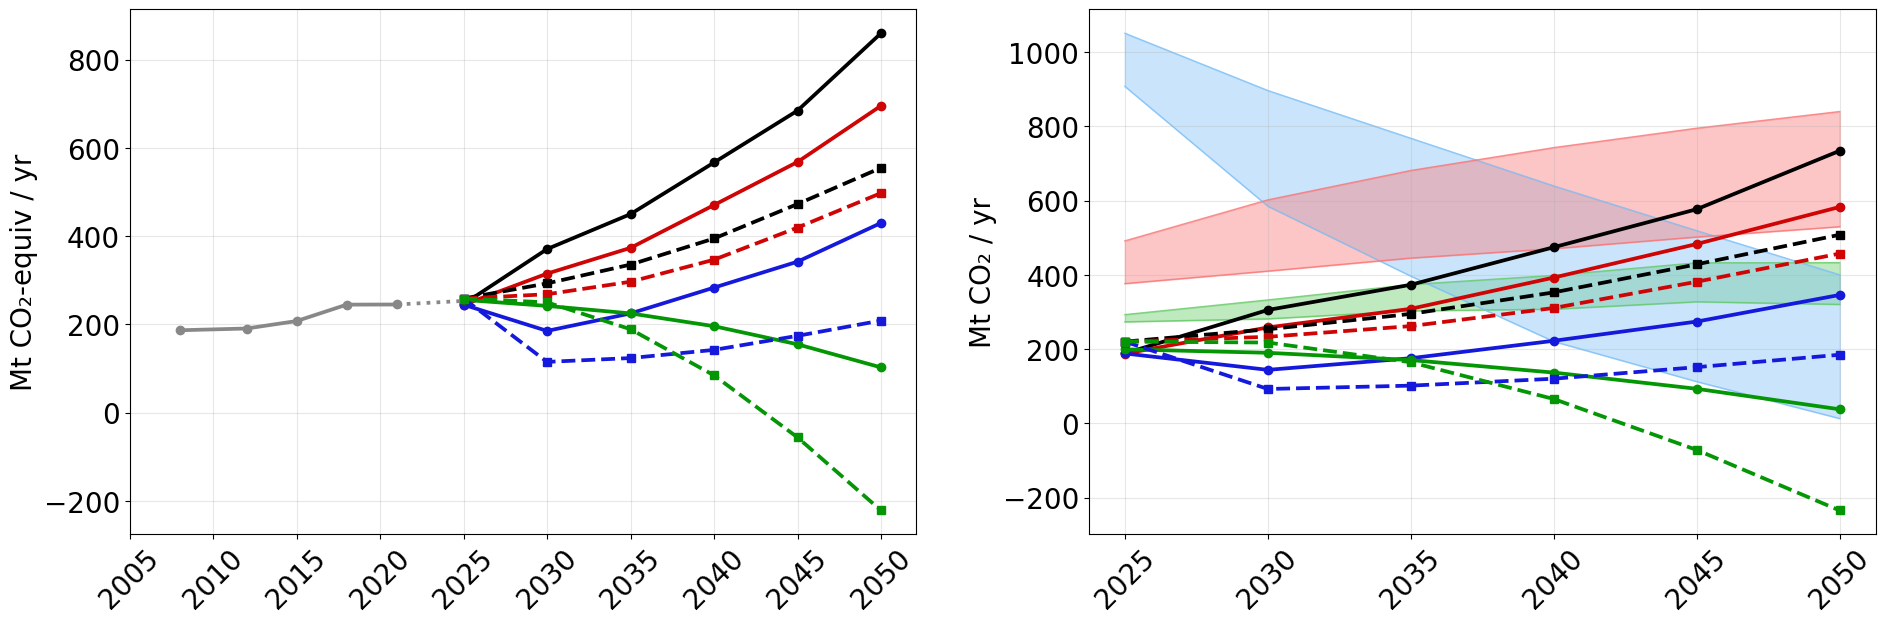

In [165]:
# ── Combined figure: Kyoto GHG (a) + CO₂ from Energy (b) ─────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch as MPatch

fig, (axA, axB) = plt.subplots(1, 2, figsize=(19, 6))

# ── Panel (a): Kyoto GHG Emissions ───────────────────────────────────────────
ext_years  = [2008, 2012, 2015, 2018, 2021]
ext_values = [186.8265, 190.791, 207.7, 244.9, 245.2]
axA.plot(ext_years, ext_values, color='#888888', marker='o', markersize=MS,
         linestyle='-', linewidth=LW)

vals_2025 = []
for sname, sdf in MSG_SCENARIOS:
    filt = sdf.filter(variable='Emissions|Kyoto Gases')
    if not filt.empty:
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = (yrs >= 2025) & (yrs <= 2050)
        axA.plot(yrs[mask], ts.values[0][mask],
                 color=SCENARIO_COLORS[sname], linestyle='-', marker='o',
                 markersize=MS, linewidth=LW)
        if 2025 in yrs:
            vals_2025.append(float(ts.values[0][yrs == 2025][0]))

for sname, sdf in GCAM_SCENARIOS:
    filt = sdf.filter(variable='Emissions|Kyoto Gases|Energy')
    if not filt.empty:
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = (yrs >= 2025) & (yrs <= 2050)
        axA.plot(yrs[mask], ts.values[0][mask],
                 color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
                 markersize=MS, linewidth=LW)
        if 2025 in yrs:
            vals_2025.append(float(ts.values[0][yrs == 2025][0]))

if vals_2025:
    avg_2025 = sum(vals_2025) / len(vals_2025)
    axA.plot([2021, 2025], [245.2, avg_2025], color='#888888',
             linestyle=':', linewidth=LW)

axA.set_ylabel('Mt CO₂-equiv / yr', fontsize=20)
axA.set_xticks(range(2005, 2051, 5))
axA.tick_params(labelsize=20)
axA.tick_params(axis='x', rotation=45)
axA.grid(alpha=0.3)

# ── Panel (b): CO₂ from Energy ───────────────────────────────────────────────
import pandas as _pd2

_es2 = _pd2.read_excel(r'D:\COMMITTED\Models\MESSAGE-GCAM\ES_Pak.xlsx', header=0)
_es2.columns = ['Time', 'Region', 'PC', 'PCC', 'ECPC', 'AP', 'Temperature']
_es15b = _es2[_es2['Temperature'].str.startswith('1.5')].set_index('Time')
_es20b = _es2[_es2['Temperature'].str.startswith('2.0')].set_index('Time')

_es_bands_b = [
    dict(label='AP',   color='#61CA61', alpha=0.4,
         lo=[float(_es15b.loc[y, 'AP'])   for y in YEARS_ALL],
         hi=[float(_es20b.loc[y, 'AP'])   for y in YEARS_ALL]),
    dict(label='PC',   color='#7BBFF7', alpha=0.4,
         lo=[float(_es15b.loc[y, 'PC'])   for y in YEARS_ALL],
         hi=[float(_es20b.loc[y, 'PC'])   for y in YEARS_ALL]),
    dict(label='ECPC', color='#FA7272', alpha=0.4,
         lo=[float(_es15b.loc[y, 'ECPC']) for y in YEARS_ALL],
         hi=[float(_es20b.loc[y, 'ECPC']) for y in YEARS_ALL]),
]

for band in _es_bands_b:
    axB.fill_between(YEARS_ALL, band['lo'], band['hi'],
                     color=band['color'], alpha=band['alpha'], zorder=0)
    axB.plot(YEARS_ALL, band['lo'], color=band['color'], linewidth=1, alpha=0.75, zorder=1)
    axB.plot(YEARS_ALL, band['hi'], color=band['color'], linewidth=1, alpha=0.75, zorder=1)

for sname, sdf in MSG_SCENARIOS:
    filt = sdf.filter(variable='Emissions|CO2|Energy')
    if not filt.empty:
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = np.isin(yrs, YEARS_ALL)
        axB.plot(yrs[mask], ts.values[0][mask],
                 color=SCENARIO_COLORS[sname], linestyle='-', marker='o',
                 markersize=MS, linewidth=LW)

for sname, sdf in GCAM_SCENARIOS:
    filt = sdf.filter(variable='Emissions|CO2|Energy')
    if not filt.empty:
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = np.isin(yrs, YEARS_ALL)
        axB.plot(yrs[mask], ts.values[0][mask],
                 color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
                 markersize=MS, linewidth=LW)

axB.set_ylabel('Mt CO₂ / yr', fontsize=20)
axB.set_xticks(range(2025, 2051, 5))
axB.tick_params(labelsize=20)
axB.tick_params(axis='x', rotation=45)
axB.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1, wspace=0.22)
fig.savefig('figures/P-emiss.svg', bbox_inches='tight')
plt.show()

# ── Legend handles (used in next cell) ────────────────────────────────────────
_scen_lines = [
    Line2D([], [], color=SCENARIO_COLORS[s], linestyle='-', linewidth=LEGEND_LW)
    for s in SCENARIO_ORDER
]
_hist_handle = Line2D([], [], color='#888888', marker='o', markersize=LEGEND_MS,
                      linestyle='-', linewidth=LEGEND_LW)
_model_handles = [
    Line2D([], [], color='#555555', linestyle='-',  marker='o', markersize=LEGEND_MS, linewidth=LEGEND_LW),
    Line2D([], [], color='#555555', linestyle='--', marker='s', markersize=LEGEND_MS, linewidth=LEGEND_LW),
]
_es_patches = [
    MPatch(facecolor='#61CA61', alpha=0.4),
    MPatch(facecolor='#7BBFF7', alpha=0.4),
    MPatch(facecolor='#FA7272', alpha=0.4),
]

leg_h = [
    _scen_lines[0], _scen_lines[1], _scen_lines[2], _scen_lines[3], _model_handles[0],
    _model_handles[1], _es_patches[0], _es_patches[1], _es_patches[2], _hist_handle,
]
leg_l = [
    'CM', 'NDC-U', 'NDC-C', 'NZ', 'MESSAGEix-Pakistan',
    'GCAM-Pakistan', 'AP (1.5\u00b0C-2.0\u00b0C)', 'PC (1.5\u00b0C-2.0\u00b0C)', 'ECPC (1.5\u00b0C-2.0\u00b0C)', 'Historical',
]

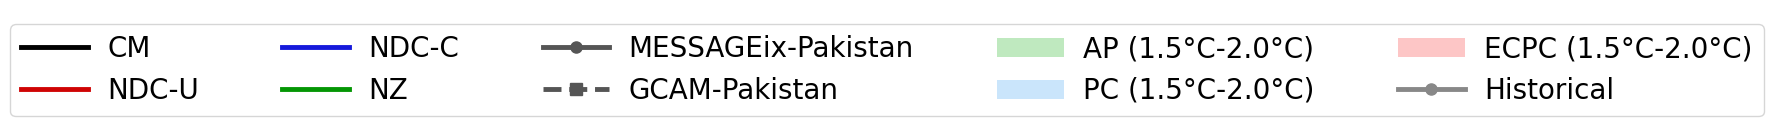

In [166]:
# ── Standalone legend figure ──────────────────────────────────────────────────
fig_leg, ax_leg = plt.subplots(figsize=(16, 1.5))
ax_leg.axis('off')

ax_leg.legend(
    handles=leg_h,
    labels=leg_l,
    ncol=5,
    loc='center',
    fontsize=20,
    frameon=True,
    handlelength=2.4,
    handletextpad=0.7,
    columnspacing=3
)

plt.tight_layout()
fig_leg.savefig('figures/L-emiss.svg', bbox_inches='tight')
plt.show()

[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:25 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:26 - pyam.core: Filtered

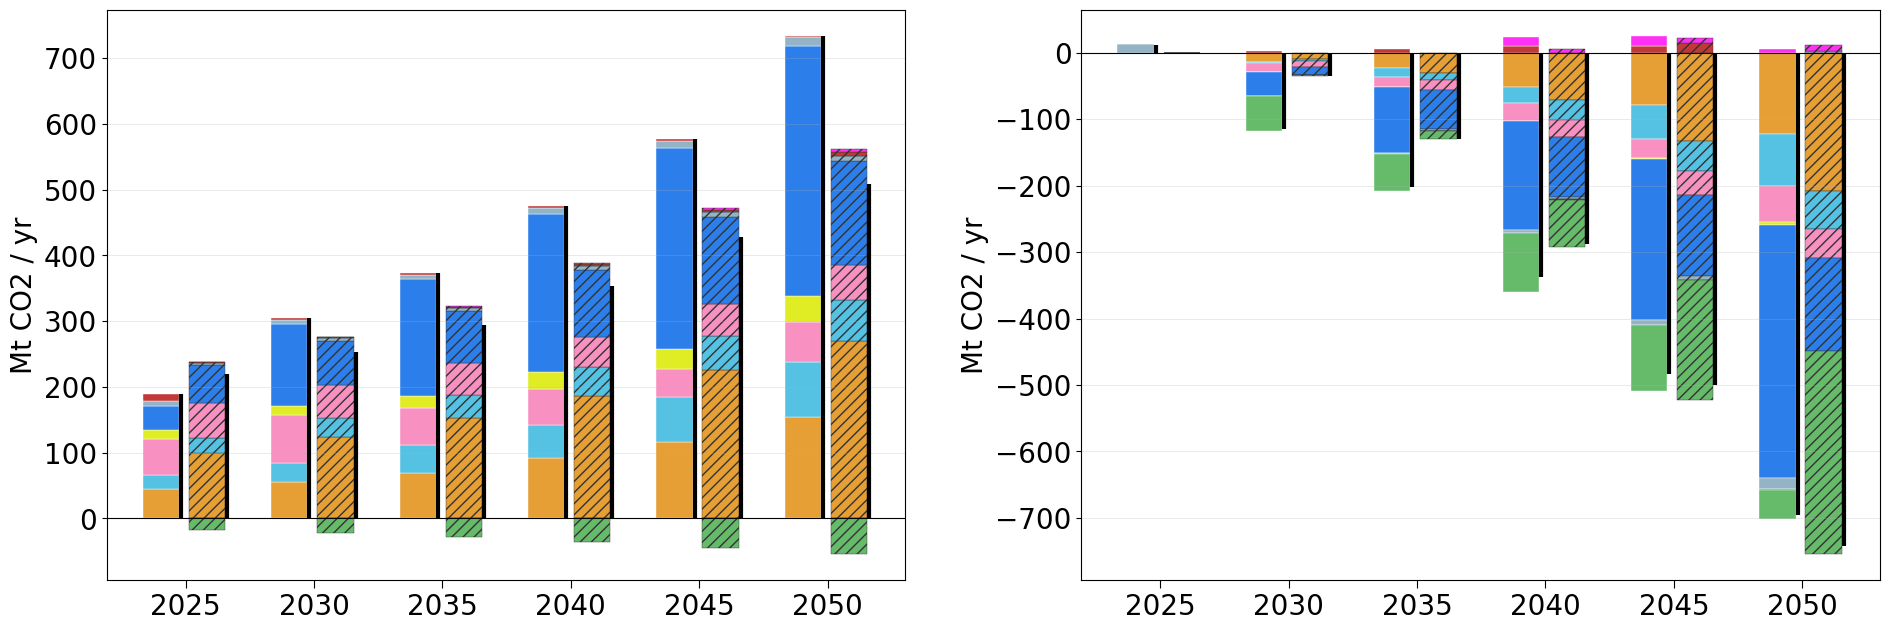

In [167]:
# ── Combined 1x2: CO2 by Sector – CM + NZ−CM difference ──────────────────────
from matplotlib.patches import Patch as _P2

fig, (axL, axR) = plt.subplots(1, 2, figsize=(19, 6.5))

_co2_vars_c = [
    'Emissions|CO2|Energy|Demand|Industry',
    'Emissions|CO2|Energy|Demand|Residential and Commercial',
    'Emissions|CO2|Energy|Demand|Transportation',
    'Emissions|CO2|Energy|Demand|Other Sector',
    'Emissions|CO2|Energy|Supply|Electricity',
    'Emissions|CO2|Energy|Supply|Gases',
    'Emissions|CO2|Energy|Supply|Liquids',
    'Emissions|CO2|Energy|Supply|Hydrogen',
]
_co2_col_c = {
    'Emissions|CO2|Energy|Demand|Industry':                   '#E69F35',
    'Emissions|CO2|Energy|Demand|Residential and Commercial': '#55C2E4',
    'Emissions|CO2|Energy|Demand|Transportation':             '#F891C1',
    'Emissions|CO2|Energy|Demand|Other Sector':               '#E0ED25',
    'Emissions|CO2|Energy|Supply|Electricity':                '#2c7feb',
    'Emissions|CO2|Energy|Supply|Gases':                      '#94B4C5',
    'Emissions|CO2|Energy|Supply|Liquids':                    '#c23737',
    'Emissions|CO2|Energy|Supply|Hydrogen':                   '#ff30f5',
    'CCS Removals':                                           '#66bb6a',
}

# ── MSG CCS mapping: supply sub-variable → CCS sequestration variables ───────
# MSG reports sub-variables NET of CCS, so we add CCS back to get gross,
# then plot total CCS as a separate negative green bar (matching GCAM treatment).
_msg_ccs_map = {
    'Emissions|CO2|Energy|Supply|Electricity': [
        'Carbon Sequestration|CCS|Fossil|Energy|Supply|Electricity',
        'Carbon Sequestration|CCS|Biomass|Energy|Supply|Electricity',
    ],
    'Emissions|CO2|Energy|Supply|Gases': [],
    'Emissions|CO2|Energy|Supply|Liquids': [
        'Carbon Sequestration|CCS|Fossil|Energy|Supply|Liquids',
        'Carbon Sequestration|CCS|Biomass|Energy|Supply|Liquids',
    ],
    'Emissions|CO2|Energy|Supply|Hydrogen': [
        'Carbon Sequestration|CCS|Fossil|Energy|Supply|Hydrogen',
        'Carbon Sequestration|CCS|Biomass|Energy|Supply|Hydrogen',
    ],
}

YEARS_EMIS = [2025, 2030, 2035, 2040, 2045, 2050]
_msg_cm_c  = next(sdf for sname, sdf in MSG_SCENARIOS  if sname == 'CM')
_gcam_cm_c = next(sdf for sname, sdf in GCAM_SCENARIOS if sname == 'CM')
_msg_nz_c  = next(sdf for sname, sdf in MSG_SCENARIOS  if sname == 'NZ')
_gcam_nz_c = next(sdf for sname, sdf in GCAM_SCENARIOS if sname == 'NZ')

w, gap_s, gap_m = 0.55, 0.15, 0.70

# Panel (a): CM scenario
x, year_mid_L = 0, []
for year in YEARS_EMIS:
    for sdf, hatch, ec, is_msg in [
        (_msg_cm_c,  None,  'white', True),
        (_gcam_cm_c, '///', '#333',  False),
    ]:
        pos_bottom = neg_bottom = 0
        total_ccs = 0
        for var in _co2_vars_c:
            val = _val(sdf, var, year)
            # MSG: gross up supply vars by adding back per-sector CCS
            if is_msg and var in _msg_ccs_map:
                ccs_for_var = sum(_val(sdf, cv, year) for cv in _msg_ccs_map[var])
                val += ccs_for_var
                total_ccs += ccs_for_var
            if val > 0:
                axL.bar(x, val, w, bottom=pos_bottom,
                        color=_co2_col_c[var], hatch=hatch, edgecolor=ec, linewidth=0.3)
                pos_bottom += val
            elif val < 0:
                axL.bar(x, val, w, bottom=neg_bottom,
                        color=_co2_col_c[var], hatch=hatch, edgecolor=ec, linewidth=0.3)
                neg_bottom += val
        # MSG: explicit CCS green bar
        if is_msg and total_ccs > 0.5:
            axL.bar(x, -total_ccs, w, bottom=neg_bottom,
                    color=_co2_col_c['CCS Removals'], hatch=hatch, edgecolor=ec, linewidth=0.3)
            neg_bottom -= total_ccs
        # GCAM: residual approach (sub-vars are already gross)
        if not is_msg:
            bar_stack = pos_bottom + neg_bottom
            true_net  = _val(sdf, 'Emissions|CO2|Energy', year)
            ccs_resid = bar_stack - true_net
            if abs(ccs_resid) > 0.5:
                axL.bar(x, -ccs_resid, w, bottom=neg_bottom,
                        color=_co2_col_c['CCS Removals'], hatch=hatch, edgecolor=ec, linewidth=0.3)
        true_net = _val(sdf, 'Emissions|CO2|Energy', year)
        axL.plot([x + w/2 + 0.03, x + w/2 + 0.03], [0, true_net],
                 color='black', linewidth=3, solid_capstyle='butt', zorder=5)
        if hatch is None:
            msg_cx_L = x + w/2 - 0.25
        else:
            gcam_cx_L = x + w/2 - 0.25
        x += w + gap_s
    year_mid_L.append((msg_cx_L + gcam_cx_L) / 2)
    x += gap_m - gap_s

axL.set_xticks(year_mid_L)
axL.set_xticklabels([str(y) for y in YEARS_EMIS], fontsize=20)
axL.tick_params(axis='x', length=6)
axL.tick_params(axis='y', labelsize=20)
axL.set_ylabel('Mt CO2 / yr', fontsize=20)
axL.grid(axis='y', alpha=0.3, linewidth=0.6)
axL.axhline(y=0, color='black', linewidth=0.8)

# Panel (b): NZ - CM difference
x, year_mid_R = 0, []
for year in YEARS_EMIS:
    for (nz_sdf, cm_sdf), hatch, ec, is_msg in [
        ((_msg_nz_c,  _msg_cm_c),  None,  'white', True),
        ((_gcam_nz_c, _gcam_cm_c), '///', '#333',  False),
    ]:
        pos_bottom = neg_bottom = 0
        total_ccs_diff = 0
        for var in _co2_vars_c:
            val_nz = _val(nz_sdf, var, year)
            val_cm = _val(cm_sdf, var, year)
            # MSG: gross up both NZ and CM, then difference
            if is_msg and var in _msg_ccs_map:
                ccs_nz = sum(_val(nz_sdf, cv, year) for cv in _msg_ccs_map[var])
                ccs_cm = sum(_val(cm_sdf, cv, year) for cv in _msg_ccs_map[var])
                val_nz += ccs_nz
                val_cm += ccs_cm
                total_ccs_diff += (ccs_nz - ccs_cm)
            val = val_nz - val_cm
            if val > 0:
                axR.bar(x, val, w, bottom=pos_bottom,
                        color=_co2_col_c[var], hatch=hatch, edgecolor=ec, linewidth=0.3)
                pos_bottom += val
            elif val < 0:
                axR.bar(x, val, w, bottom=neg_bottom,
                        color=_co2_col_c[var], hatch=hatch, edgecolor=ec, linewidth=0.3)
                neg_bottom += val
        # MSG: explicit CCS difference as green bar
        if is_msg and abs(total_ccs_diff) > 0.5:
            axR.bar(x, -total_ccs_diff, w, bottom=neg_bottom,
                    color=_co2_col_c['CCS Removals'], hatch=hatch, edgecolor=ec, linewidth=0.3)
            neg_bottom -= total_ccs_diff
        # GCAM: residual approach
        if not is_msg:
            bar_stack = pos_bottom + neg_bottom
            true_net  = (_val(nz_sdf, 'Emissions|CO2|Energy', year)
                         - _val(cm_sdf, 'Emissions|CO2|Energy', year))
            ccs_resid = bar_stack - true_net
            if abs(ccs_resid) > 0.5:
                axR.bar(x, -ccs_resid, w, bottom=neg_bottom,
                        color=_co2_col_c['CCS Removals'], hatch=hatch, edgecolor=ec, linewidth=0.3)
        true_net = (_val(nz_sdf, 'Emissions|CO2|Energy', year)
                    - _val(cm_sdf, 'Emissions|CO2|Energy', year))
        axR.plot([x + w/2 + 0.03, x + w/2 + 0.03], [0, true_net],
                 color='black', linewidth=3, solid_capstyle='butt', zorder=5)
        if hatch is None:
            msg_cx_R = x + w/2 - 0.25
        else:
            gcam_cx_R = x + w/2 - 0.25
        x += w + gap_s
    year_mid_R.append((msg_cx_R + gcam_cx_R) / 2)
    x += gap_m - gap_s

axR.set_xticks(year_mid_R)
axR.set_xticklabels([str(y) for y in YEARS_EMIS], fontsize=20)
axR.tick_params(axis='x', length=6)
axR.tick_params(axis='y', labelsize=20)
axR.set_ylabel('Mt CO2 / yr', fontsize=20)
axR.grid(axis='y', alpha=0.3, linewidth=0.6)
axR.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1, wspace=0.22)
fig.savefig('figures/P-co2-sectoral.svg', bbox_inches='tight')
plt.show()

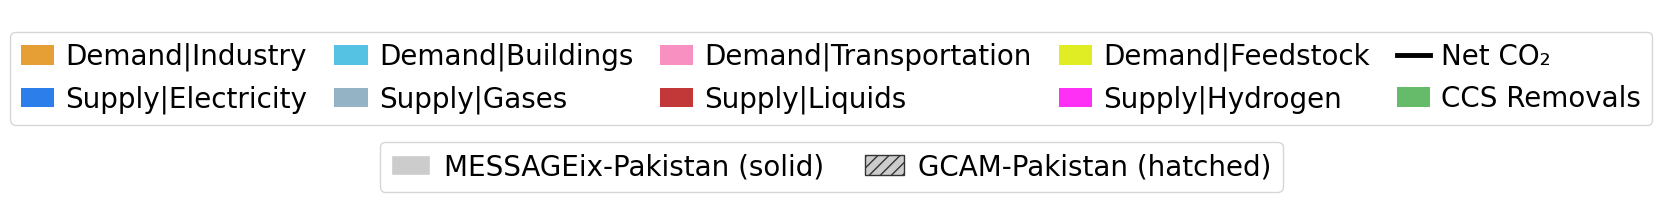

In [168]:
# ── Standalone sector + model legend ─────────────────────────────────────────
from matplotlib.lines import Line2D

_co2_labels_c = {
    'Emissions|CO2|Energy|Demand|Industry':                   'Demand|Industry',
    'Emissions|CO2|Energy|Demand|Residential and Commercial': 'Demand|Buildings',
    'Emissions|CO2|Energy|Demand|Transportation':             'Demand|Transportation',
    'Emissions|CO2|Energy|Demand|Other Sector':               'Demand|Feedstock',
    'Emissions|CO2|Energy|Supply|Electricity':                'Supply|Electricity',
    'Emissions|CO2|Energy|Supply|Gases':                      'Supply|Gases',
    'Emissions|CO2|Energy|Supply|Liquids':                    'Supply|Liquids',
    'Emissions|CO2|Energy|Supply|Hydrogen':                   'Supply|Hydrogen',
}

_demand_vars_c = [v for v in _co2_vars_c if 'Demand' in v]
_supply_vars_c = [v for v in _co2_vars_c if 'Supply' in v and v in _co2_labels_c]

_row1 = [Patch(facecolor=_co2_col_c[v], label=_co2_labels_c[v]) for v in _demand_vars_c] + [
    Line2D([0], [0], color='black', linewidth=LEGEND_LW, label='Net CO₂')
]
_row2 = [Patch(facecolor=_co2_col_c[v], label=_co2_labels_c[v]) for v in _supply_vars_c] + [
    Patch(facecolor=_co2_col_c['CCS Removals'], label='CCS Removals')
]

# zip transpose so matplotlib's column-major fill gives row-major display
sector_handles = [h for col in zip(_row1, _row2) for h in col]

fig_leg2, ax_leg2 = plt.subplots(figsize=(16, 1.9))
ax_leg2.axis('off')

fig_leg2.legend(handles=sector_handles, ncol=5,
                loc='upper center', bbox_to_anchor=(0.5, 0.88),
                fontsize=20, frameon=True,
                handlelength=1.2, handletextpad=0.4, columnspacing=0.97)

fig_leg2.legend(handles=[
    Patch(facecolor='#ccc', edgecolor='white',             label='MESSAGEix-Pakistan (solid)'),
    Patch(facecolor='#ccc', hatch='///', edgecolor='#333', label='GCAM-Pakistan (hatched)'),
], ncol=2, loc='upper center', bbox_to_anchor=(0.5, 0.3),
   fontsize=20, frameon=True, handlelength=1.4, handletextpad=0.5, columnspacing=1.5)

plt.tight_layout()
fig_leg2.savefig('figures/L-co2.svg', bbox_inches='tight')
plt.show()

## 3. Electricity Generation Mix

In [169]:
import string
from matplotlib.patches import Patch

YEARS_FIG = [2025, 2035, 2050]

FUEL_COLORS = {
    'Coal w/o CCS':    '#1c1208',
    'Coal w/ CCS':     '#7a5548',
    'Gas w/o CCS':     '#577e91',
    'Gas w/ CCS':      '#829fad',
    'Oil':             '#c0392b',
    'Hydro':           '#4fc3f7',
    'Nuclear':         "#ffa9f8",
    'Geothermal':      '#7b1fa2',
    'Solar':           '#f9d71c',
    'Wind':            '#fb8c00',
    'Biomass w/o CCS': '#2e7d32',
    'Biomass w/ CCS':  '#66bb6a',
}

FUEL_ORDER = [
    'Coal w/o CCS', 'Coal w/ CCS',
    'Gas w/o CCS',  'Gas w/ CCS',
    'Oil',           'Hydro',
    'Solar',         'Wind',
    'Nuclear',       'Geothermal',
    'Biomass w/o CCS', 'Biomass w/ CCS',
]

def _fuel_key(var):
    parts = var.split('|')
    if 'w/ CCS' in var:
        return f'{parts[-2]} w/ CCS'
    elif 'w/o CCS' in var:
        return f'{parts[-2]} w/o CCS'
    else:
        return parts[-1]

col_defs = [
    {
        'title': 'Primary Energy',
        'vars': [
            'Primary Energy|Coal|w/o CCS',    'Primary Energy|Coal|w/ CCS',
            'Primary Energy|Gas|w/o CCS',     'Primary Energy|Gas|w/ CCS',
            'Primary Energy|Oil',
            'Primary Energy|Hydro',
            'Primary Energy|Solar',           'Primary Energy|Wind',
            'Primary Energy|Nuclear',         'Primary Energy|Geothermal',
            'Primary Energy|Biomass|w/o CCS', 'Primary Energy|Biomass|w/ CCS',
        ],
    },
    {
        'title': 'Electricity Generation',
        'vars': [
            'Secondary Energy|Electricity|Coal|w/o CCS',
            'Secondary Energy|Electricity|Coal|w/ CCS',
            'Secondary Energy|Electricity|Gas|w/o CCS',
            'Secondary Energy|Electricity|Gas|w/ CCS',
            'Secondary Energy|Electricity|Oil',
            'Secondary Energy|Electricity|Hydro',
            'Secondary Energy|Electricity|Solar',
            'Secondary Energy|Electricity|Wind',
            'Secondary Energy|Electricity|Nuclear',
            'Secondary Energy|Electricity|Geothermal',
            'Secondary Energy|Electricity|Biomass|w/o CCS',
            'Secondary Energy|Electricity|Biomass|w/ CCS',
        ],
    },
]

w, gap_s, gap_m = 0.55, 0.08, 0.42

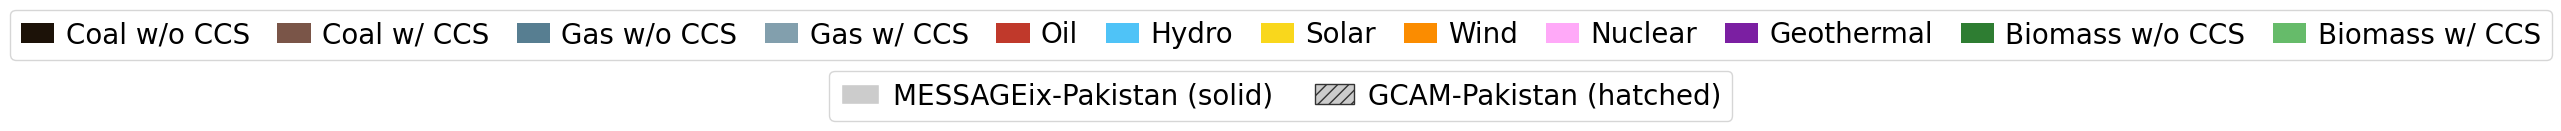

In [170]:
# ── Figure 3: Legends ─────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(6, 1))
ax3.axis('off')

fuel_patches = [Patch(facecolor=FUEL_COLORS[fk], label=fk) for fk in FUEL_ORDER]
fig3.legend(handles=fuel_patches, ncol=12,
            loc='upper center', bbox_to_anchor=(0.5, 0.99),
            fontsize=20, frameon=True,
            handlelength=1.2, handletextpad=0.4, columnspacing=1.0)

fig3.legend(handles=[
    Patch(facecolor='#ccc', edgecolor='white',             label='MESSAGEix-Pakistan (solid)'),
    Patch(facecolor='#ccc', hatch='///', edgecolor='#333', label='GCAM-Pakistan (hatched)'),
], ncol=2, loc='upper center', bbox_to_anchor=(0.5, 0.38),
   fontsize=20, frameon=True, handlelength=1.4, handletextpad=0.5, columnspacing=1.5)

plt.tight_layout()
fig3.savefig('figures/L-primary-secondary.svg', bbox_inches='tight')
plt.show()

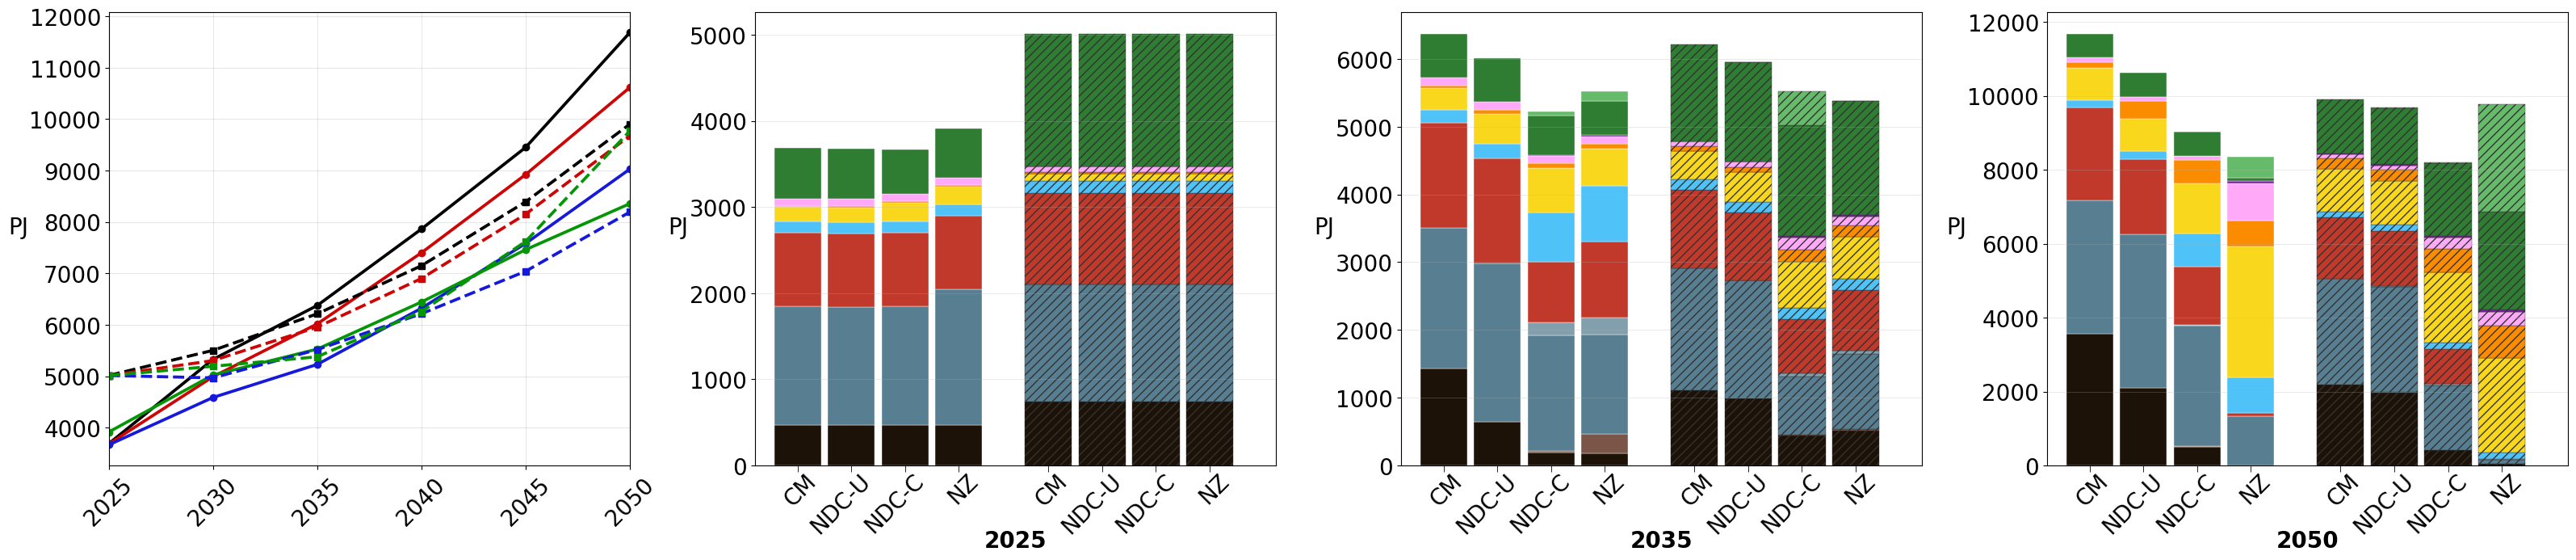

In [171]:
# ── Combined 1x4: line plot + Primary Energy stacked bars (2025/2035/2050) ────
gap_m = 0.42  # distance between MESSAGEix and GCAM bar groups
pad_l, pad_r = 0.5, 0.5  # data-unit padding left of first bar / right of last bar
from matplotlib.lines import Line2D

with plt.rc_context({'axes.xmargin': 0}):
    fig, axes = plt.subplots(1, 4, figsize=(32, 7))

    # Panel 0: line plot
    ax_ln = axes[0]
    for sname, sdf in MSG_SCENARIOS:
        filt = sdf.filter(variable='Primary Energy')
        if filt.empty:
            continue
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = np.isin(yrs, YEARS_ALL)
        ax_ln.plot(yrs[mask], ts.values[0][mask],
                   color=SCENARIO_COLORS[sname], linestyle='-', marker='o',
                   markersize=MS, linewidth=LW)

    for sname, sdf in GCAM_SCENARIOS:
        filt = sdf.filter(variable='Primary Energy')
        if filt.empty:
            continue
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = np.isin(yrs, YEARS_ALL)
        ax_ln.plot(yrs[mask], ts.values[0][mask] * 1000,
                   color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
                   markersize=MS, linewidth=LW)

    ax_ln.set_ylabel('PJ', fontsize=20, rotation=0, labelpad=10)
    ax_ln.set_xticks(YEARS_ALL)
    ax_ln.tick_params(labelsize=20)
    ax_ln.tick_params(axis='x', rotation=45)
    ax_ln.grid(alpha=0.3)

    # Panels 1-3: stacked bars per year
    for ax, year in zip(axes[1:], YEARS_FIG):
        x, tick_pos, tick_lbl, bar_centers = 0, [], [], []
        for sname, sdf in MSG_SCENARIOS:
            bottom = 0
            for var in col_defs[0]['vars']:
                val = _val(sdf, var, year)
                if val <= 0:
                    continue
                ax.bar(x, val, w, bottom=bottom,
                       color=FUEL_COLORS[_fuel_key(var)], edgecolor='white', linewidth=0.3)
                bottom += val
            bar_centers.append(x)
            tick_pos.append(x + w / 2)
            tick_lbl.append(sname)
            x += w + gap_s
        x += gap_m
        for sname, sdf in GCAM_SCENARIOS:
            bottom = 0
            for var in col_defs[0]['vars']:
                val = _val(sdf, var, year, scale=1000)
                if val <= 0:
                    continue
                ax.bar(x, val, w, bottom=bottom,
                       color=FUEL_COLORS[_fuel_key(var)], hatch='///', edgecolor='#333', linewidth=0.3)
                bottom += val
            bar_centers.append(x)
            tick_pos.append(x + w / 2)
            tick_lbl.append(sname)
            x += w + gap_s
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, fontsize=20, rotation=45, ha='right')
        ax.tick_params(axis='x', which='major', length=0)
        ax.set_xticks(bar_centers, minor=True)
        ax.tick_params(axis='x', which='minor', length=6, bottom=True, labelbottom=False)
        ax.tick_params(axis='y', labelsize=20)
        ax.grid(axis='y', alpha=0.3, linewidth=0.6)
        ax.text(0.5, -0.18, str(year), transform=ax.transAxes,
                ha='center', fontsize=20, fontweight='bold')
        ax.set_ylabel('PJ', fontsize=20, rotation=0, labelpad=10)
        ax.autoscale(False)
        ax.set_xlim(-pad_l, bar_centers[-1] + w / 2 + pad_r)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.24)
    fig.savefig('figures/P-primary.svg', bbox_inches='tight')
    plt.show()

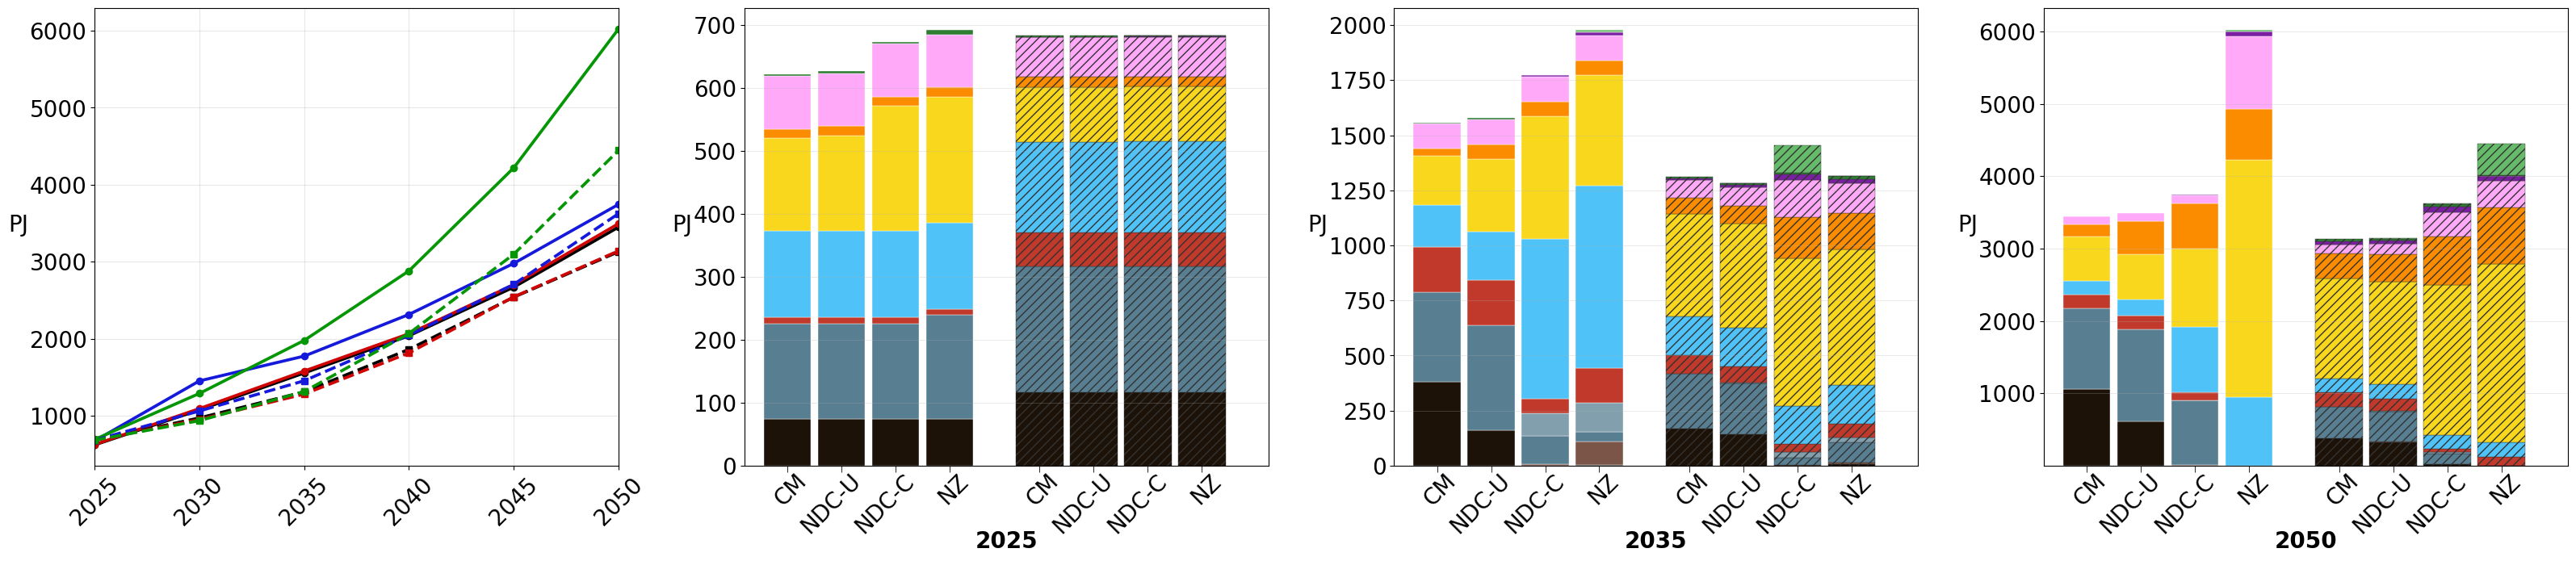

In [172]:
# ── Combined 1x4: line plot + Electricity Generation stacked bars ─────────────
gap_m = 0.42  # distance between MESSAGEix and GCAM bar groups
pad_l, pad_r = 0.5, 0.5  # data-unit padding left of first bar / right of last bar
from matplotlib.lines import Line2D

with plt.rc_context({'axes.xmargin': 0}):
    fig, axes = plt.subplots(1, 4, figsize=(32, 7))

    # Panel 0: line plot
    ax_ln = axes[0]
    for sname, sdf in MSG_SCENARIOS:
        filt = sdf.filter(variable='Secondary Energy|Electricity')
        if filt.empty:
            continue
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = np.isin(yrs, YEARS_ALL)
        ax_ln.plot(yrs[mask], ts.values[0][mask],
                   color=SCENARIO_COLORS[sname], linestyle='-', marker='o',
                   markersize=MS, linewidth=LW)

    for sname, sdf in GCAM_SCENARIOS:
        filt = sdf.filter(variable='Secondary Energy|Electricity')
        if filt.empty:
            continue
        ts  = filt.timeseries()
        yrs = ts.columns.astype(int)
        mask = np.isin(yrs, YEARS_ALL)
        ax_ln.plot(yrs[mask], ts.values[0][mask] * 1000,
                   color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
                   markersize=MS, linewidth=LW)

    ax_ln.set_ylabel('PJ', fontsize=20, rotation=0, labelpad=10)
    ax_ln.set_xticks(YEARS_ALL)
    ax_ln.tick_params(labelsize=20)
    ax_ln.tick_params(axis='x', rotation=45)
    ax_ln.grid(alpha=0.3)

    # Panels 1-3: stacked bars per year
    for ax, year in zip(axes[1:], YEARS_FIG):
        x, tick_pos, tick_lbl, bar_centers = 0, [], [], []
        for sname, sdf in MSG_SCENARIOS:
            bottom = 0
            for var in col_defs[1]['vars']:
                val = _val(sdf, var, year)
                if val <= 0:
                    continue
                ax.bar(x, val, w, bottom=bottom,
                       color=FUEL_COLORS[_fuel_key(var)], edgecolor='white', linewidth=0.3)
                bottom += val
            bar_centers.append(x)
            tick_pos.append(x + w / 2)
            tick_lbl.append(sname)
            x += w + gap_s
        x += gap_m
        for sname, sdf in GCAM_SCENARIOS:
            bottom = 0
            for var in col_defs[1]['vars']:
                val = _val(sdf, var, year, scale=1000)
                if val <= 0:
                    continue
                ax.bar(x, val, w, bottom=bottom,
                       color=FUEL_COLORS[_fuel_key(var)], hatch='///', edgecolor='#333', linewidth=0.3)
                bottom += val
            bar_centers.append(x)
            tick_pos.append(x + w / 2)
            tick_lbl.append(sname)
            x += w + gap_s
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, fontsize=20, rotation=45, ha='right')
        ax.tick_params(axis='x', which='major', length=0)
        ax.set_xticks(bar_centers, minor=True)
        ax.tick_params(axis='x', which='minor', length=6, bottom=True, labelbottom=False)
        ax.tick_params(axis='y', labelsize=20)
        ax.grid(axis='y', alpha=0.3, linewidth=0.6)
        ax.text(0.5, -0.18, str(year), transform=ax.transAxes,
                ha='center', fontsize=20, fontweight='bold')
        ax.set_ylabel('PJ', fontsize=20, rotation=0, labelpad=10)
        ax.autoscale(False)
        ax.set_xlim(-pad_l, bar_centers[-1] + w / 2 + pad_r)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.24)
    fig.savefig('figures/P-electricity.svg', bbox_inches='tight')
    plt.show()

C:\Users\Arfa Yaseen\AppData\Local\Temp\ipykernel_36748\199854863.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


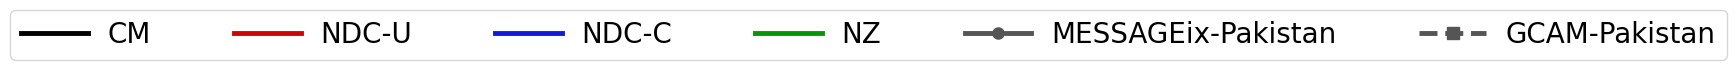

In [173]:
# ── Standalone legend: Primary Energy ─────────────────────────────────────────
_scen_lines_pe = [
    Line2D([], [], color=SCENARIO_COLORS[s], linestyle='-', linewidth=LEGEND_LW)
    for s in ['CM', 'NDC-U', 'NDC-C', 'NZ']
]
_model_handles_pe = [
    Line2D([], [], color='#555555', linestyle='-',  marker='o', markersize=LEGEND_MS, linewidth=LEGEND_LW),
    Line2D([], [], color='#555555', linestyle='--', marker='s', markersize=LEGEND_MS, linewidth=LEGEND_LW),
]
leg_h_pe = [
    _scen_lines_pe[0], _scen_lines_pe[1], _scen_lines_pe[2], _scen_lines_pe[3],
    _model_handles_pe[0], _model_handles_pe[1],
]
leg_l_pe = [
    'CM', 'NDC-U', 'NDC-C', 'NZ',
    'MESSAGEix-Pakistan', 'GCAM-Pakistan',
]

fig_leg_pe, ax_leg_pe = plt.subplots(figsize=(6, 0.4))
ax_leg_pe.axis('off')

ax_leg_pe.legend(
    handles=leg_h_pe,
    labels=leg_l_pe,
    ncol=6,
    loc='center',
    fontsize=20,
    frameon=True,
    handlelength=2.4,
    handletextpad=0.7,
    columnspacing=3,
)

plt.tight_layout()
fig_leg_pe.savefig('figures/L-scenarios.svg', bbox_inches='tight')
plt.show()

In [174]:
# ── Final Energy by Sector — shared setup ────────────────────────────────────
vars_FE_tr = [
    'Final Energy|Transportation|Electricity',
    'Final Energy|Transportation|Gases',
    'Final Energy|Transportation|Hydrogen',
    'Final Energy|Transportation|Liquids',
]
colors_FE_tr = {
    'Final Energy|Transportation|Electricity': '#26d5e9',
    'Final Energy|Transportation|Gases':       '#a1a1a1',
    'Final Energy|Transportation|Hydrogen':    '#FF43D6',
    'Final Energy|Transportation|Liquids':     '#FCA147',
}

vars_FE_rc = [
    'Final Energy|Residential and Commercial|Electricity',
    'Final Energy|Residential and Commercial|Gases',
    'Final Energy|Residential and Commercial|Hydrogen',
    'Final Energy|Residential and Commercial|Liquids',
    'Final Energy|Residential and Commercial|Other',
    'Final Energy|Residential and Commercial|Solids|Coal',
    'Final Energy|Residential and Commercial|Solids|Biomass',
]
colors_FE_rc = {
    'Final Energy|Residential and Commercial|Electricity':    '#26d5e9',
    'Final Energy|Residential and Commercial|Gases':          '#a1a1a1',
    'Final Energy|Residential and Commercial|Hydrogen':       '#FF43D6',
    'Final Energy|Residential and Commercial|Liquids':        '#FCA147',
    'Final Energy|Residential and Commercial|Other':          '#bdbdbd',
    'Final Energy|Residential and Commercial|Solids|Coal':    '#2E2D2D',
    'Final Energy|Residential and Commercial|Solids|Biomass': '#63b163',
}

vars_FE_ind = [
    'Final Energy|Industry|Electricity',
    'Final Energy|Industry|Gases',
    'Final Energy|Industry|Hydrogen',
    'Final Energy|Industry|Liquids',
    'Final Energy|Industry|Solids|Coal',
    'Final Energy|Industry|Solids|Biomass',
    'Final Energy|Industry|Other',
]
colors_FE_ind = {
    'Final Energy|Industry|Electricity':    '#26d5e9',
    'Final Energy|Industry|Gases':          '#a1a1a1',
    'Final Energy|Industry|Hydrogen':       '#FF43D6',
    'Final Energy|Industry|Liquids':        '#FCA147',
    'Final Energy|Industry|Solids|Coal':    '#2E2D2D',
    'Final Energy|Industry|Solids|Biomass': '#63b163',
    'Final Energy|Industry|Other':          '#bdbdbd',
}

PLOT_YEARS = [2025, 2050]

FUEL_LEGEND_FE = [
    ('Electricity',  '#26d5e9'),
    ('Gases',        '#a1a1a1'),
    ('Hydrogen',     '#FF43D6'),
    ('Liquids',      '#FCA147'),
    ('Coal',         '#2E2D2D'),
    ('Biomass',      '#63b163'),
    ('Solar Thermal',"#eff15e"),
]

_FE_MODEL_GROUPS = [
    ('MESSAGEix', MSG_SCENARIOS,  1,    None,  'white'),
    ('GCAM',      GCAM_SCENARIOS, 1000, '///', '#333'),
]


In [175]:
# ── Final Energy by Sector — shared setup ────────────────────────────────────
vars_FE_tr = [
    'Final Energy|Transportation|Electricity',
    'Final Energy|Transportation|Gases',
    'Final Energy|Transportation|Hydrogen',
    'Final Energy|Transportation|Liquids',
]
colors_FE_tr = {
    'Final Energy|Transportation|Electricity': '#26d5e9',
    'Final Energy|Transportation|Gases':       '#a1a1a1',
    'Final Energy|Transportation|Hydrogen':    '#FF43D6',
    'Final Energy|Transportation|Liquids':     '#FCA147',
}

vars_FE_rc = [
    'Final Energy|Residential and Commercial|Electricity',
    'Final Energy|Residential and Commercial|Gases',
    'Final Energy|Residential and Commercial|Hydrogen',
    'Final Energy|Residential and Commercial|Liquids',
    'Final Energy|Residential and Commercial|Other',
    'Final Energy|Residential and Commercial|Solids|Coal',
    'Final Energy|Residential and Commercial|Solids|Biomass',
]
colors_FE_rc = {
    'Final Energy|Residential and Commercial|Electricity':    '#26d5e9',
    'Final Energy|Residential and Commercial|Gases':          '#a1a1a1',
    'Final Energy|Residential and Commercial|Hydrogen':       '#FF43D6',
    'Final Energy|Residential and Commercial|Liquids':        '#FCA147',
    'Final Energy|Residential and Commercial|Other':          '#bdbdbd',
    'Final Energy|Residential and Commercial|Solids|Coal':    '#2E2D2D',
    'Final Energy|Residential and Commercial|Solids|Biomass': '#63b163',
}

vars_FE_ind = [
    'Final Energy|Industry|Electricity',
    'Final Energy|Industry|Gases',
    'Final Energy|Industry|Hydrogen',
    'Final Energy|Industry|Liquids',
    'Final Energy|Industry|Solids|Coal',
    'Final Energy|Industry|Solids|Biomass',
    'Final Energy|Industry|Other',
]
colors_FE_ind = {
    'Final Energy|Industry|Electricity':    '#26d5e9',
    'Final Energy|Industry|Gases':          '#a1a1a1',
    'Final Energy|Industry|Hydrogen':       '#FF43D6',
    'Final Energy|Industry|Liquids':        '#FCA147',
    'Final Energy|Industry|Solids|Coal':    '#2E2D2D',
    'Final Energy|Industry|Solids|Biomass': '#63b163',
    'Final Energy|Industry|Other':          '#bdbdbd',
}

PLOT_YEARS = [2025, 2050]

FUEL_LEGEND_FE = [
    ('Electricity',  '#26d5e9'),
    ('Gases',        '#a1a1a1'),
    ('Hydrogen',     '#FF43D6'),
    ('Liquids',      '#FCA147'),
    ('Coal',         '#2E2D2D'),
    ('Biomass',      '#63b163'),
    ('Solar Thermal',"#eff15e"),
]

_FE_MODEL_GROUPS = [
    ('MESSAGEix', MSG_SCENARIOS,  1,    None,  'white'),
    ('GCAM',      GCAM_SCENARIOS, 1000, '///', '#333'),
]


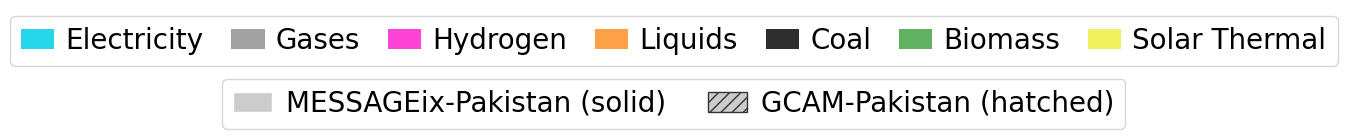

In [176]:
# ── Standalone legend: Final Energy by Sector ─────────────────────────────────
fig_leg_fe, ax_leg_fe = plt.subplots(figsize=(10, 1.4))
ax_leg_fe.axis('off')

fe_fuel_patches = [Patch(facecolor=c, label=l) for l, c in FUEL_LEGEND_FE]
fig_leg_fe.legend(handles=fe_fuel_patches, ncol=7,
                  loc='upper center', bbox_to_anchor=(0.5, 0.95),
                  fontsize=20, frameon=True,
                  handlelength=1.2, handletextpad=0.4, columnspacing=1.0)

fig_leg_fe.legend(handles=[
    Patch(facecolor='#ccc', edgecolor='white',             label='MESSAGEix-Pakistan (solid)'),
    Patch(facecolor='#ccc', hatch='///', edgecolor='#333', label='GCAM-Pakistan (hatched)'),
], ncol=2, loc='upper center', bbox_to_anchor=(0.5, 0.5),
   fontsize=20, frameon=True, handlelength=1.4, handletextpad=0.5, columnspacing=1.5)

plt.tight_layout()
fig_leg_fe.savefig('figures/L-final-energy.svg', bbox_inches='tight')
plt.show()

[WARNING] 21:32:55 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:55 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:55 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 21:32:56 - pyam.core: Filtered IamDataFrame is empty!


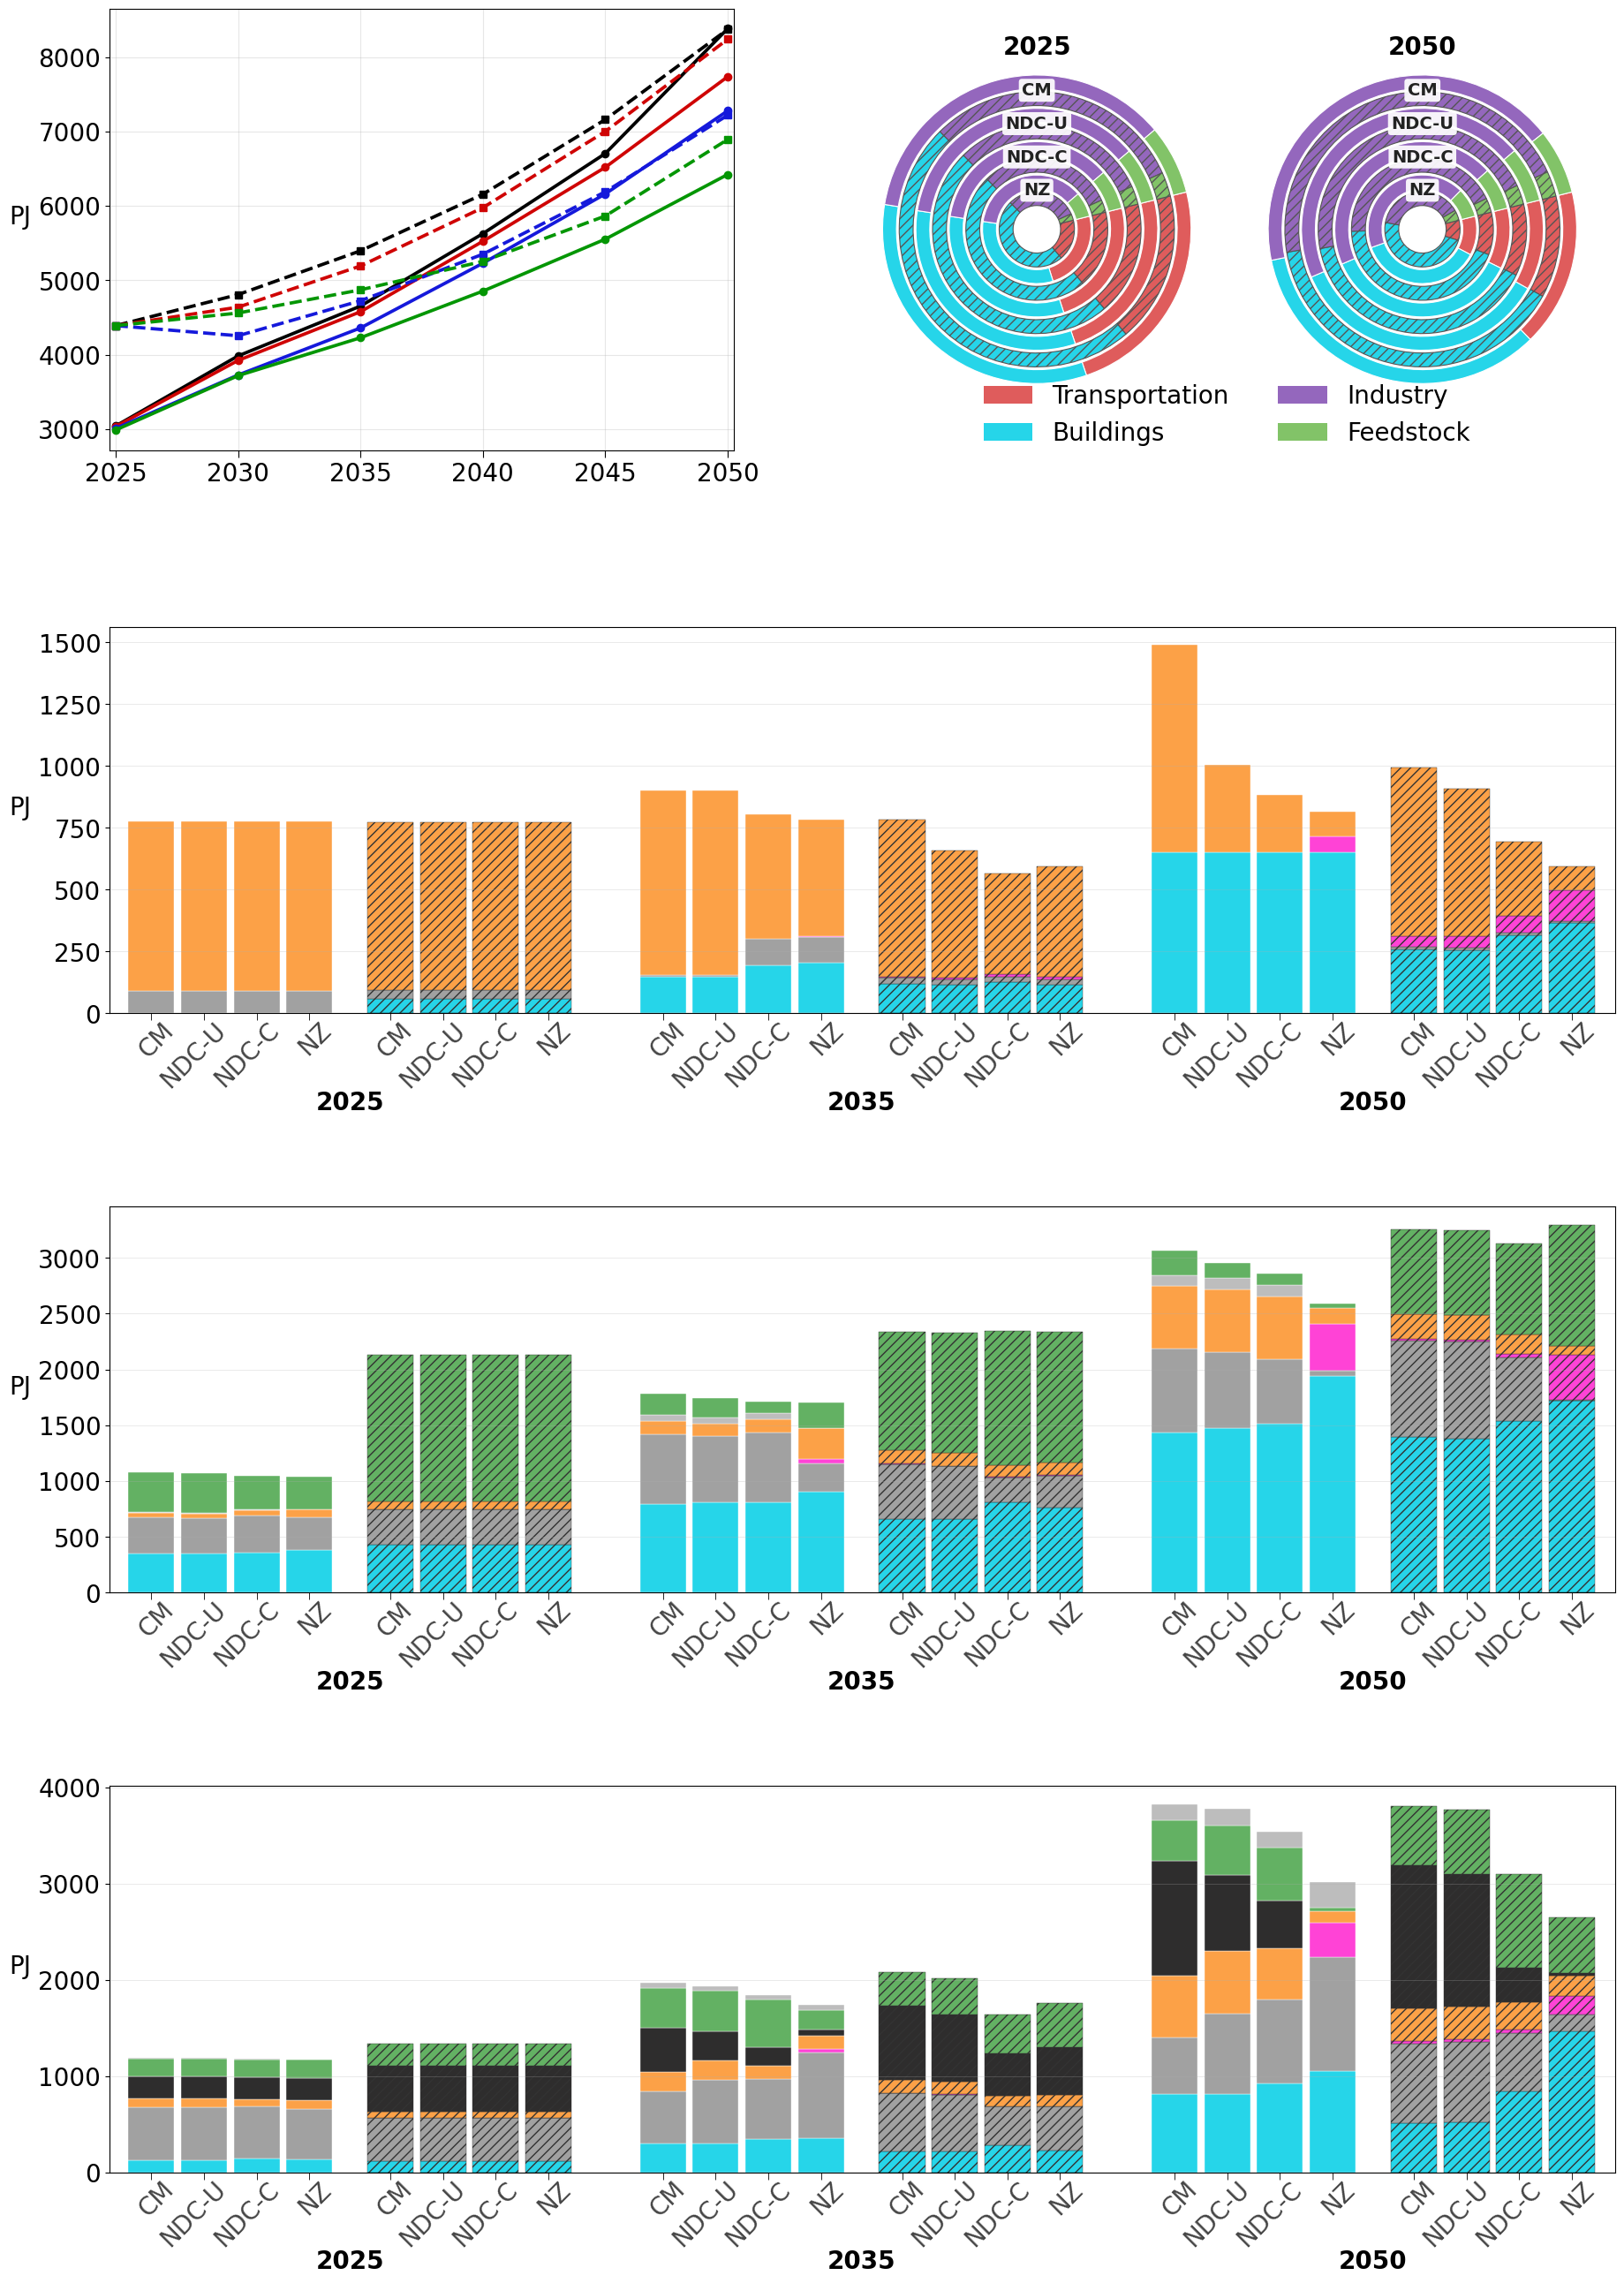

In [191]:
# ── Total FE line (a) + sector donuts (b) ; Transport / Buildings / Industry ──
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Sector order: Transport, Buildings, Industry
_SECTOR_ROWS = [
    ('Transportation', vars_FE_tr,  colors_FE_tr),
    ('Buildings',      vars_FE_rc,  colors_FE_rc),
    ('Industry',       vars_FE_ind, colors_FE_ind),
]

# Sector totals for the composition donuts (panel b).
# Note: Non-Energy Use (feedstock) is reported OUTSIDE the model's 'Final Energy'
# total, so these donuts depict Final Energy + Non-Energy Use.
_FE_SECTORS = [
    ('Transportation', 'Final Energy|Transportation',             '#df5c5c'),
    ('Buildings',      'Final Energy|Residential and Commercial', '#26d5e9'),
    ('Industry',       'Final Energy|Industry',                   '#9467bd'),
    ('Feedstock',      'Final Energy|Non-Energy Use',             "#82C368"),
]
_SEC_COLORS = [c for _, _, c in _FE_SECTORS]

# Donut rings grouped by SCENARIO: each scenario gets two adjacent rings,
# MESSAGEix (solid) then GCAM (hatched, ×1000) — matching the bar-panel convention.
_MSG_BY_SCEN  = {s: sdf for s, sdf in MSG_SCENARIOS}
_GCAM_BY_SCEN = {s: sdf for s, sdf in GCAM_SCENARIOS}
_SCEN_ORDER   = [s for s, _ in MSG_SCENARIOS]            # CM, NDC-U, NDC-C, NZ
_DONUT_MODELS = [('MESSAGEix', _MSG_BY_SCEN,  1,    None,  'white'),
                 ('GCAM',      _GCAM_BY_SCEN, 1000, '///', '#555')]
# ring order outer→inner: (scenario_label, sdf, scale, hatch, edgecolor)
_DONUT_RINGS = [(s, mdict[s], scale, hatch, ec)
                for s in _SCEN_ORDER
                for _, mdict, scale, hatch, ec in _DONUT_MODELS]

_PLOT_YEARS_3 = [2025, 2035, 2050]
w_fe, gap_s_fe, gap_m_fe, gap_year_fe = 0.55, 0.08, 0.42, 0.4
pad_l, pad_r = 0.5, -0.45   # data-unit padding left of first bar / right of last bar

fig = plt.figure(figsize=(22, 25))

# Row 0: line plot (a) left, two sector donuts (b: 2025 & 2050) right.
# Slim spacer column LEFT of the donuts shifts them rightward.
# top=1.06 / bottom=0.82 lifts the donuts upward; bars stay at top=0.74.
gs_top  = GridSpec(1, 4, figure=fig, top=1.02, bottom=0.82, wspace=0.0,
                   width_ratios=[1.7, 0.30, 1.05, 1.05])
gs_bars = GridSpec(3, 1, figure=fig, top=0.74, bottom=0.04, hspace=0.5)

# ── Panel a: Total Final Energy line plot ─────────────────────────────────────
ax_top = fig.add_subplot(gs_top[0])
for sname, sdf in MSG_SCENARIOS:
    filt = sdf.filter(variable='Final Energy')
    if filt.empty:
        continue
    ts  = filt.timeseries()
    yrs = ts.columns.astype(int)
    mask = np.isin(yrs, YEARS_ALL)
    ax_top.plot(yrs[mask], ts.values[0][mask],
                color=SCENARIO_COLORS[sname], linestyle='-', marker='o',
                markersize=MS, linewidth=LW)
for sname, sdf in GCAM_SCENARIOS:
    filt = sdf.filter(variable='Final Energy')
    if filt.empty:
        continue
    ts  = filt.timeseries()
    yrs = ts.columns.astype(int)
    mask = np.isin(yrs, YEARS_ALL)
    ax_top.plot(yrs[mask], ts.values[0][mask] * 1000,
                color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
                markersize=MS, linewidth=LW)
ax_top.set_xlim(2024.75, 2050.25)
ax_top.set_ylabel('PJ', fontsize=20, rotation=0, labelpad=15)
ax_top.set_xticks(YEARS_ALL)
ax_top.tick_params(labelsize=20)
ax_top.tick_params(axis='x', length=6)
ax_top.grid(alpha=0.3)
ax_top.set_title('', loc='left')

# ── Panel b: Final Energy by sector — concentric donuts, 8 scenario rings ─────
# Per year, outer→inner, paired by scenario:
#   CM(MSG solid), CM(GCAM hatched), NDC-U(MSG), NDC-U(GCAM), ... NZ(MSG), NZ(GCAM).
# GCAM is scaled ×1000. startangle=14 keeps the 12-o'clock labels clear of boundaries.
# One scenario label is centred across each solid+hatched ring pair.
r_outer, ring_w, ring_gap = 1.0, 0.09, 0.018
for yr, cell_gs in [(2025, gs_top[2]), (2050, gs_top[3])]:
    axp = fig.add_subplot(cell_gs)
    # draw all 8 rings
    for ri, (sname, sdf, scale_f, hatch, ec) in enumerate(_DONUT_RINGS):
        sector_tot = [_val(sdf, svar, yr, scale=scale_f) for _, svar, _ in _FE_SECTORS]
        radius = r_outer - ri * (ring_w + ring_gap)
        axp.pie(sector_tot, colors=_SEC_COLORS, radius=radius,
                startangle=14, counterclock=False,
                wedgeprops=dict(width=ring_w, edgecolor=ec, linewidth=0.8, hatch=hatch))
    # one label per scenario, centred over its two-ring (MSG+GCAM) band, in the 12-o'clock split
    for pair_idx, sname in enumerate(_SCEN_ORDER):
        ri_outer = pair_idx * 2                # MSG ring index for this scenario
        ri_inner = ri_outer + 1                # GCAM ring index
        outer_edge = r_outer - ri_outer * (ring_w + ring_gap)
        inner_edge = (r_outer - ri_inner * (ring_w + ring_gap)) - ring_w
        r_label = (outer_edge + inner_edge) / 2
        axp.text(0, r_label, sname, ha='center', va='center',
                 fontsize=14, fontweight='bold', color='#222',
                 bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.92))
    # year label ABOVE the donut
    axp.text(0, r_outer + 0.10, str(yr), ha='center', va='bottom',
             fontsize=20, fontweight='bold')
    axp.set_title('', loc='left')

# sector legend below the donuts, fontsize 20
_sec_handles = [Patch(facecolor=c, label=l) for l, _, c in _FE_SECTORS]
fig.legend(handles=_sec_handles, loc='upper center', bbox_to_anchor=(0.7, 0.86),
           ncol=2, fontsize=20, frameon=False)

# ── Bar panels: one axis per sector, all years combined ───────────────────────
for row_idx, (row_label, variables, colors) in enumerate(_SECTOR_ROWS):
    ax = fig.add_subplot(gs_bars[row_idx])

    x, tick_pos, tick_lbl, bar_centers = 0, [], [], []

    for year in _PLOT_YEARS_3:
        year_bar_centers = []

        for model_label, scenarios, scale_f, hatch, ec in _FE_MODEL_GROUPS:
            for sname, sdf in scenarios:
                bottom = 0
                for var in variables:
                    val = _val(sdf, var, year, scale=scale_f)
                    if val <= 0:
                        continue
                    ax.bar(x, val, w_fe, bottom=bottom,
                           color=colors[var], hatch=hatch,
                           edgecolor=ec, linewidth=0.3)
                    bottom += val
                year_bar_centers.append(x)
                bar_centers.append(x)
                tick_pos.append(x + w_fe / 2 + 0.05)
                tick_lbl.append(sname)
                x += w_fe + gap_s_fe
            x += gap_m_fe - gap_s_fe

        year_mid = (year_bar_centers[0] + year_bar_centers[-1]) / 2
        ax.text(year_mid, -0.25, str(year),
                transform=ax.get_xaxis_transform(),
                ha='center', fontsize=20, fontweight='bold', clip_on=False)

        x += gap_year_fe

    ax.set_xlim(-pad_l, x - gap_year_fe + pad_r)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, fontsize=20, color='#444', rotation=45, ha='right')
    ax.tick_params(axis='x', which='major', length=0)
    ax.set_xticks(bar_centers, minor=True)
    ax.tick_params(axis='x', which='minor', length=6, bottom=True, labelbottom=False)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(axis='y', alpha=0.3, linewidth=0.6)
    ax.set_ylabel('PJ', fontsize=20, rotation=0, labelpad=15)
    ax.set_title('', loc='left')

fig.savefig('figures/P-final-energy-sectors.svg', bbox_inches='tight')
plt.show()

In [178]:
# ── Cumulative Energy Supply Investment by Category ─────────────────────
# Near-term (2025–2035) vs Long-term (2025–2050), MSG only

INV_GROUPS = {
    'Electricity|Fossil w/o CCS': [
        'Investment|Energy Supply|Electricity|Coal|w/o CCS',
        'Investment|Energy Supply|Electricity|Gas|w/o CCS',
        'Investment|Energy Supply|Electricity|Oil|w/o CCS',
    ],
    'Electricity|Fossil w/ CCS': [
        'Investment|Energy Supply|Electricity|Coal|w/ CCS',
        'Investment|Energy Supply|Electricity|Gas|w/ CCS',
        'Investment|Energy Supply|Electricity|Oil|w/ CCS',
    ],
    'Electricity|Non-Biomass Renewables': [
        'Investment|Energy Supply|Electricity|Solar|PV',
        'Investment|Energy Supply|Electricity|Solar|CSP',
        'Investment|Energy Supply|Electricity|Wind|Onshore',
        'Investment|Energy Supply|Electricity|Wind|Offshore',
        'Investment|Energy Supply|Electricity|Hydro',
        'Investment|Energy Supply|Electricity|Geothermal',
    ],
    'Electricity|Biomass': [
        'Investment|Energy Supply|Electricity|Biomass|w/ CCS',
        'Investment|Energy Supply|Electricity|Biomass|w/o CCS',
    ],
    'Electricity|Nuclear': [
        'Investment|Energy Supply|Electricity|Nuclear',
    ],
    'Electricity|H2 Fuelcell': [
        'Investment|Energy Supply|Electricity|Other',
    ],
    'Electricity|Grid & Storage': [
        'Investment|Energy Supply|Electricity|Electricity Storage',
        'Investment|Energy Supply|Electricity|Transmission and Distribution',
    ],
    'Extraction|Fossil': [
        'Investment|Energy Supply|Extraction|Coal',
        'Investment|Energy Supply|Extraction|Gas',
        'Investment|Energy Supply|Extraction|Oil',
    ],
    'Liquids': [
        'Investment|Energy Supply|Liquids',
    ],
    'Gases': [
        'Investment|Energy Supply|Gases',
    ],
    'Other': [
        'Investment|Energy Supply|Other',
    ],
    'CO2 Transport and Storage': [
        'Investment|Energy Supply|CO2 Transport and Storage',
    ],
    'Hydrogen': [
        'Investment|Energy Supply|Hydrogen',
    ],
}

FUEL_COLORS = {
    'Coal w/o CCS':    '#1c1208',
    'Coal w/ CCS':     '#7a5548',
    'Gas w/o CCS':     '#577e91',
    'Gas w/ CCS':      '#829fad',
    'Oil':             '#c0392b',
    'Hydro':           '#4fc3f7',
    'Nuclear':         "#ffa9f8",
    'Geothermal':      '#7b1fa2',
    'Solar':           '#f9d71c',
    'Wind':            '#fb8c00',
    'Biomass w/o CCS': '#2e7d32',
    'Biomass w/ CCS':  '#66bb6a',
}

INV_COLORS = {
    'Electricity|Fossil w/o CCS'     : '#1c1208',
    'Electricity|Fossil w/ CCS'      : "#a4a2ca",
    'Electricity|Non-Biomass Renewables': '#ffba26',
    'Electricity|Biomass'            : '#2d7a2d',
    'Electricity|Nuclear'            : '#ffa9f8',
    'Electricity|H2 Fuelcell'        : '#ff9358',
    'Electricity|Grid & Storage'     : '#0077ff',
    'Extraction|Fossil'              : '#966746',
    'Liquids'                        : '#d33636',
    'Gases'                          : '#577e91',
    'CO2 Transport and Storage'      : '#7b1fa2',
    'Hydrogen'                       : '#ff30f5',
    'Other'                          : "#98b2be",
}

GROUP_ORDER = [
    'Electricity|Fossil w/o CCS',
    'Electricity|Fossil w/ CCS',
    'Electricity|Non-Biomass Renewables',
    'Electricity|Biomass',
    'Electricity|Nuclear',
    'Electricity|H2 Fuelcell',
    'Electricity|Grid & Storage',
    'Extraction|Fossil',
    'Liquids',
    'Gases',
    'CO2 Transport and Storage',
    'Hydrogen',
    'Other',
]

PERIODS = [
    ('NT', [2025, 2030, 2035]),
    ('LT', [2025, 2030, 2035, 2040, 2045, 2050]),
]

def _cum_inv(sdf, variables, years):
    total = 0
    for var in variables:
        for y in years:
            total += _val(sdf, var, y) or 0
    return total * 5



w_inv, gap_s_inv, gap_m_inv = 0.55, 0.15, 0.80



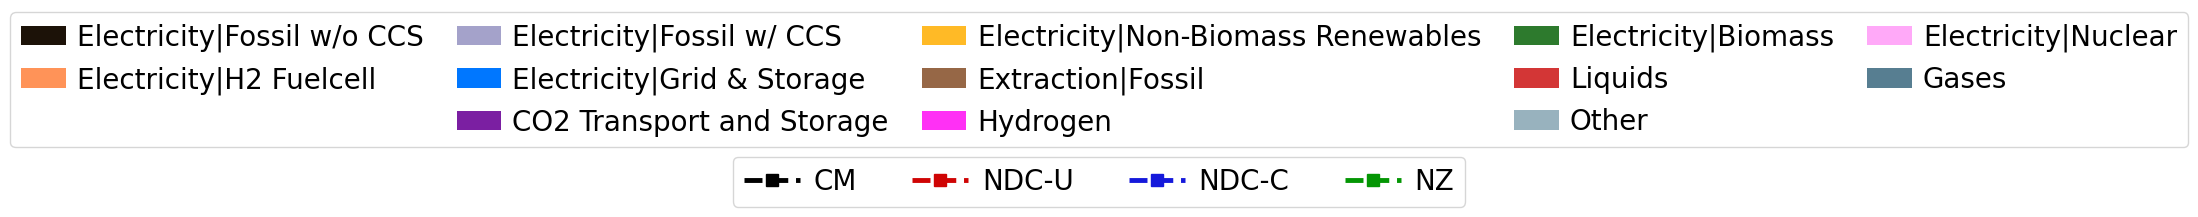

In [179]:
# ── Standalone legend: Investment ─────────────────────────────────────────────
# INV_COLORS and SCENARIO_COLORS must be in scope — run the investment cell first
from matplotlib.lines import Line2D

def _patch(label):
    return Patch(facecolor=INV_COLORS[label], label=label)

_blank = Patch(facecolor='none', edgecolor='none', label='')

_scen_line_handles = [
    Line2D([], [], color=SCENARIO_COLORS[s], linestyle='--', marker='s',
           markersize=LEGEND_MS, linewidth=LEGEND_LW, label=s)
    for s in SCENARIO_ORDER
]

# Define desired display rows (patches only)
_row1 = [
    _patch('Electricity|Fossil w/o CCS'), _patch('Electricity|Fossil w/ CCS'),
    _patch('Electricity|Non-Biomass Renewables'), _patch('Electricity|Biomass'),
    _patch('Electricity|Nuclear'),
]
_row2 = [
    _patch('Electricity|H2 Fuelcell'),
    _patch('Electricity|Grid & Storage'),
    _patch('Extraction|Fossil'), _patch('Liquids'), _patch('Gases'),
]
_row3 = [
    _blank, _patch('CO2 Transport and Storage'), _patch('Hydrogen'), _patch('Other'), _blank,
]

# zip transpose for row-major display
patch_handles = [h for col in zip(_row1, _row2, _row3) for h in col]

fig_leg_inv, ax_leg_inv = plt.subplots(figsize=(16, 1.9))
ax_leg_inv.axis('off')

fig_leg_inv.legend(handles=patch_handles, ncol=5,
                   loc='upper center', bbox_to_anchor=(0.5, 0.98),
                   fontsize=20, frameon=True,
                   handlelength=1.6, handletextpad=0.4, columnspacing=1.2)

fig_leg_inv.legend(handles=_scen_line_handles, ncol=4,
                   loc='upper center', bbox_to_anchor=(0.5, 0.22),
                   fontsize=20, frameon=True,
                   handlelength=2.0, handletextpad=0.5, columnspacing=2.0)

plt.tight_layout()
fig_leg_inv.savefig('figures/L-investment.svg', bbox_inches='tight')
plt.show()

In [180]:
# ── GCAM prices: shadow carbon price + consumer electricity price ─────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PRICES_PATH = 'data/Prices.xlsx'

CONVERT_UNITS = False
C_FACTOR = 1.76 / 3.667   # 1990$/tC -> 2010$/tCO2
E_FACTOR = 3.12            # 1975$/GJ -> 2010$/GJ

CP_LABEL = 'USD$_{2010}$/tCO$_2$' if CONVERT_UNITS else 'USD$_{2010}$/tC'
EL_LABEL = 'USD$_{2010}$/GJ'      if CONVERT_UNITS else 'USD$_{2010}$/GJ'
CP_SCALE = C_FACTOR if CONVERT_UNITS else 1.0
EL_SCALE = E_FACTOR if CONVERT_UNITS else 1.0

YEARS_P = [2025, 2030, 2035, 2040, 2045, 2050]

_pr = pd.read_excel(PRICES_PATH)
_pr['sector'] = _pr['sector'].astype(str)


def price_series(sector, scenario, scale=1.0, years=YEARS_P):
    row = _pr[(_pr['sector'] == sector) & (_pr['scenario'] == scenario)]
    if row.empty:
        return np.array(years), np.full(len(years), np.nan)
    return np.array(years), np.array([float(row.iloc[0][y]) * scale for y in years])




[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:36 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:37 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:37 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:37 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 20:00:37 - pyam.core: Filtered

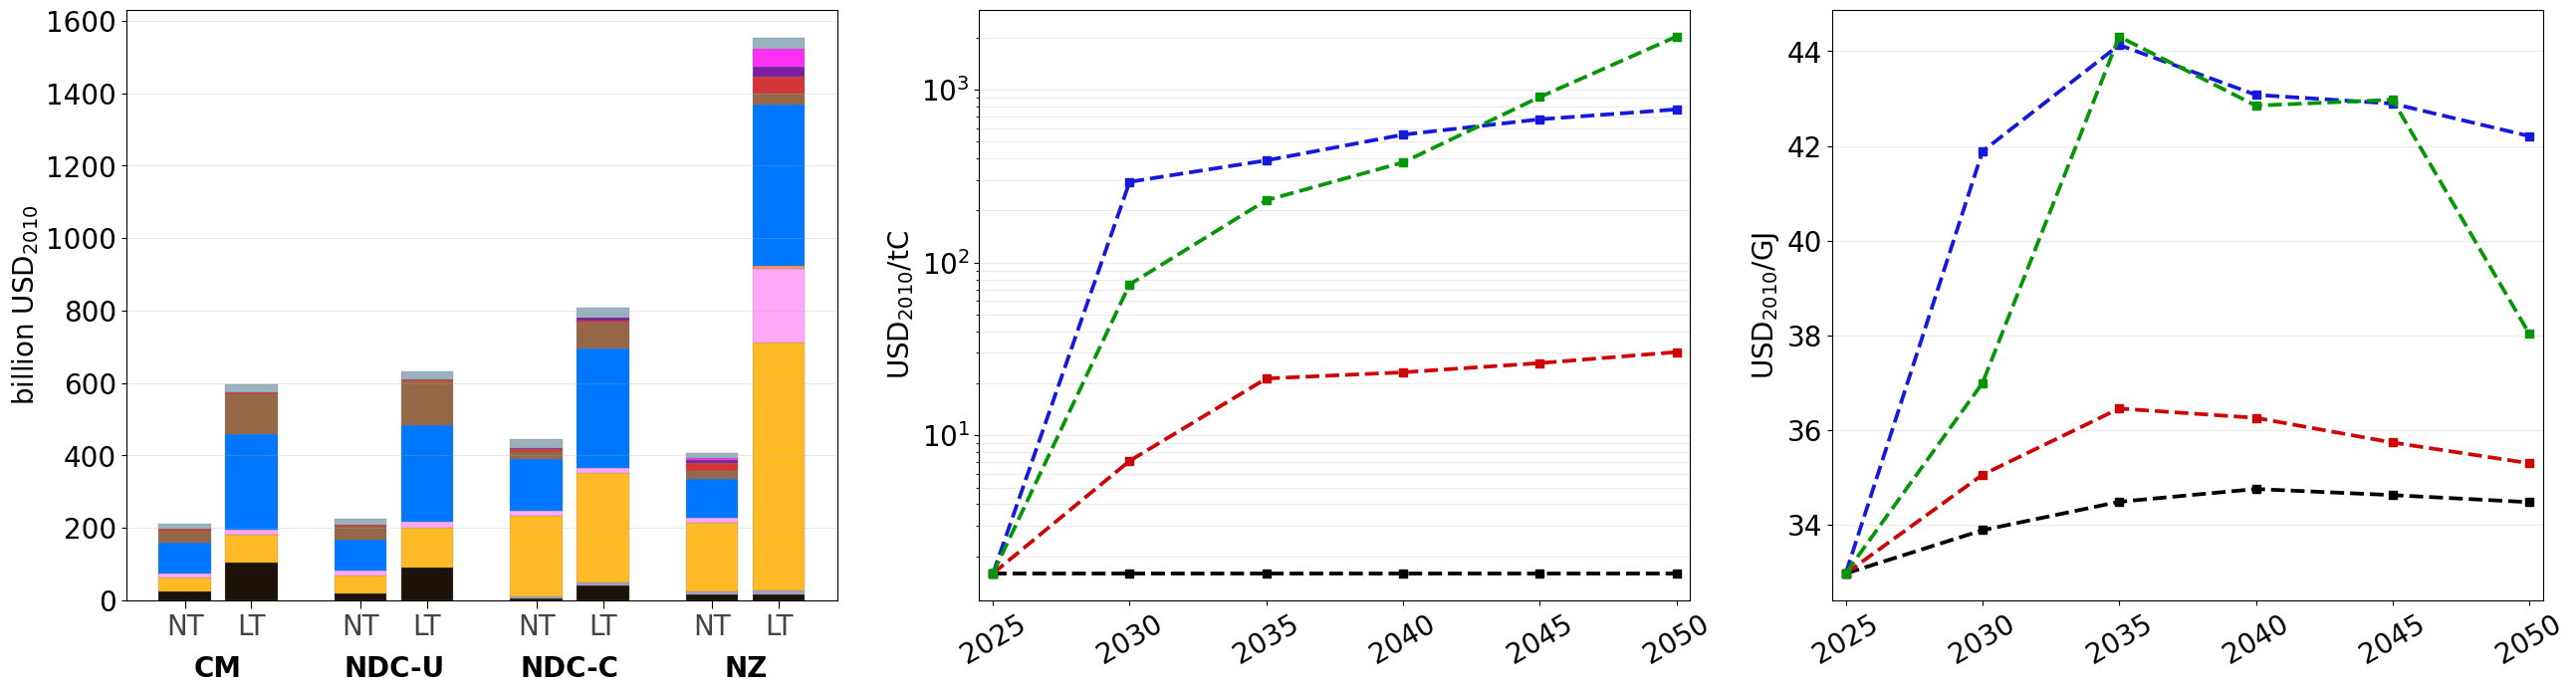

In [181]:
# ── Combined 1x3: Investment | Carbon price | Electricity price ───────────────
from matplotlib.gridspec import GridSpec

gap_m_combined = 0.6   # space between scenario bar pairs — edit here

fig = plt.figure(figsize=(26, 7))
gs = GridSpec(1, 3, figure=fig)
ax_inv = fig.add_subplot(gs[0])
ax_cp  = fig.add_subplot(gs[1])
ax_el  = fig.add_subplot(gs[2])

# ── Investment ────────────────────────────────────────────────────────────────
x = 0
_tick_pos, _tick_lbl, _scen_mid = [], [], []

for sname, msg_sdf in MSG_SCENARIOS:
    _pair_xs = []
    for period_label, years in PERIODS:
        bottom = 0
        for grp in GROUP_ORDER:
            val = _cum_inv(msg_sdf, INV_GROUPS[grp], years)
            if val > 0.5:
                ax_inv.bar(x, val, w_inv, bottom=bottom,
                           color=INV_COLORS[grp], edgecolor='grey', linewidth=0.2)
                bottom += val
        cx = x + w_inv / 2 - 0.275
        _tick_pos.append(cx)
        _tick_lbl.append(period_label)
        _pair_xs.append(cx)
        x += w_inv + gap_s_inv
    _scen_mid.append(((_pair_xs[0] + _pair_xs[-1]) / 2, sname))
    x += gap_m_combined - gap_s_inv

ax_inv.set_xticks(_tick_pos)
ax_inv.set_xticklabels(_tick_lbl, fontsize=20, color='#444')
ax_inv.tick_params(axis='x', length=6)
ax_inv.tick_params(axis='y', labelsize=20)
ax_inv.set_ylabel('billion USD$_{2010}$', fontsize=20)
ax_inv.grid(axis='y', alpha=0.3, linewidth=0.6)

for xm, sname in _scen_mid:
    ax_inv.text(xm, -0.13, sname,
                transform=ax_inv.get_xaxis_transform(),
                ha='center', fontsize=20, fontweight='bold', clip_on=False)

# ── Carbon price ──────────────────────────────────────────────────────────────
for sname in SCENARIO_ORDER:
    yrs, vals = price_series('carbon-storage', sname, CP_SCALE)
    ax_cp.plot(yrs, vals, color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
               markersize=MS, linewidth=LW)
ax_cp.set_yscale('log')
ax_cp.set_ylabel(CP_LABEL, fontsize=20)
ax_cp.set_xticks(YEARS_P)
ax_cp.tick_params(labelsize=20)
ax_cp.tick_params(axis='x', rotation=30)
ax_cp.margins(x=0.02)
ax_cp.grid(axis='y', which='both', alpha=0.25)

# ── Electricity price ─────────────────────────────────────────────────────────
for sname in SCENARIO_ORDER:
    yrs, vals = price_series('elect_td_bld', sname, EL_SCALE)
    ax_el.plot(yrs, vals, color=SCENARIO_COLORS[sname], linestyle='--', marker='s',
               markersize=MS, linewidth=LW)
ax_el.set_ylabel(EL_LABEL, fontsize=20)
ax_el.set_xticks(YEARS_P)
ax_el.tick_params(labelsize=20)
ax_el.tick_params(axis='x', rotation=30)
ax_el.margins(x=0.02)
ax_el.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
fig.savefig('figures/P-investment-prices.svg', bbox_inches='tight')
plt.show()